# PREDICTIVE ML MODEL TRAINING FOR HYDRAULIC PRESS THROUGH SYNTHETICALLY GENERATED DATASET

### Set-up & Imports

In [ ]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import gc
import json
import math
import joblib
import onnxmltools
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from onnxmltools.convert.common.data_types import FloatTensorType as OnnxFloatTensorType
from skl2onnx.common.data_types import FloatTensorType as Skl2OnnxFloatTensorType
from onnxmltools.utils import save_model as save_onnx_model
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import r2_score
from IPython.display import display
from scipy.stats import spearmanr
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from scipy.stats import ks_2samp



# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols


def free_memory(variable_names: list):
    """Free memory by deleting variables and running garbage collector."""
    for var_name in variable_names:
        if var_name in globals():
            try:
                del globals()[var_name]
            except Exception:
                pass
    gc.collect()

# HYDRAULIC PRESS SPECIFIC CONSTANTS
    # These constants are tuned for Hydraulic Press RUL scale (30K-50K min range)
    # Similar to Process Pump scale for optimal ML performance
STAGE1_CRITICAL_THRESHOLD = 300    # Stage-1 classifier trigger (minutes) 5 hours
STAGE2A_CRITICAL_THRESHOLD = 200   # Stage-2A regressor max RUL (minutes) ~3.3 hours
PROJECT_CRITICAL_THRESHOLD = 100   # Final project metric threshold (minutes) ~1.6 hours
ACCURACY_TOLERANCE = 10            # +/- 10 min tolerance (same as Process Pump)
SENSOR_COLUMNS = [
                    'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                    'ram_position_deviation', 'press_force', 'vibration',
                    'flow_rate', 'motor_current'
                ]

# Create models directory if it doesn't exist
if not os.path.exists("models_and_features"):
    os.makedirs("models_and_features")
    if not os.path.exists("models_and_features/hydraulic_press"):
        os.makedirs("models_and_features/hydraulic_press")
    if not os.path.exists("models_and_features") or not os.path.exists("models_and_features/hydraulic_press"):
        raise RuntimeError("Failed to create models_and_features directory")

save_path= "models_and_features/hydraulic_press/"

print_footer("SETUP AND IMPORTS COMPLETE")



----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Dataset Load & Basic Inspection

In [2]:
# 1/ Dataset Load & Basic Inspection
# Memory-optimized: Load directly to pandas, avoid duplicate copies

print_header("1/ DATASET LOAD")

# Define file paths
long_life_csv_path = "synthetic_hydraulic_press_data_long_life.csv"
short_life_csv_path = "synthetic_hydraulic_press_data_short_life.csv"

# Load datasets with optimized dtypes to save memory
dtype_mapping = {
                    'cycle_id': 'int32',
                    'time_min': 'int32',
                    'total_rul': 'int32',
                    'current_rul': 'int32',
                    'hydraulic_pressure': 'float32',
                    'oil_temperature': 'float32',
                    'oil_contamination': 'float32',
                    'ram_position_deviation': 'float32',
                    'press_force': 'float32',
                    'vibration': 'float32',
                    'flow_rate': 'float32',
                    'motor_current': 'float32'
                }

print("Loading Long-Life dataset...")
df_long_life = pd.read_csv(long_life_csv_path, dtype=dtype_mapping)

print("Loading Short-Life dataset...")
df_short_life = pd.read_csv(short_life_csv_path, dtype=dtype_mapping)

# Print dataset info
print("\n--- Long-Life Dataset")
print(f"Shape: {df_long_life.shape}")
print(f"Memory: {df_long_life.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RUL range: {df_long_life['current_rul'].min()} - {df_long_life['current_rul'].max()} minutes")
print(f"Cycles: {df_long_life['cycle_id'].nunique()}")

print("\n--- Short-Life Dataset")
print(f"Shape: {df_short_life.shape}")
print(f"Memory: {df_short_life.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"RUL range: {df_short_life['current_rul'].min()} - {df_short_life['current_rul'].max()} minutes")
print(f"Cycles: {df_short_life['cycle_id'].nunique()}")

# Critical region analysis
long_critical_ratio = (df_long_life['current_rul'] <= PROJECT_CRITICAL_THRESHOLD).mean() * 100
short_critical_ratio = (df_short_life['current_rul'] <= PROJECT_CRITICAL_THRESHOLD).mean() * 100

print(f"\n--- Critical Region (RUL <= {PROJECT_CRITICAL_THRESHOLD})")
print(f"Long-Life: {long_critical_ratio:.4f}%")
print(f"Short-Life: {short_critical_ratio:.2f}%")

print_footer("DATASET LOAD COMPLETE")


1/ DATASET LOAD
Loading Long-Life dataset...
Loading Short-Life dataset...

--- Long-Life Dataset
Shape: (19751687, 12)
Memory: 948.1 MB
RUL range: 0 - 711434 minutes
Cycles: 50

--- Short-Life Dataset
Shape: (261692, 12)
Memory: 12.6 MB
RUL range: 0 - 2998 minutes
Cycles: 150

--- Critical Region (RUL <= 100)
Long-Life: 0.0256%
Short-Life: 5.79%

----------------------------------------------------------------------
DATASET LOAD COMPLETE
----------------------------------------------------------------------


In [3]:
# 1A/ Long-Life Dataset Summary
print_header("1A/ LONG-LIFE DATASET SUMMARY")

# Basic statistics
print("Column types:")
print(df_long_life.dtypes)
print("-" * 40)

print("\nStatistical summary:")
print(df_long_life.describe().T)
print("-" * 40)

print(f"\nNull values: {df_long_life.isnull().sum().sum()}")
print(f"Duplicate rows: {df_long_life.duplicated().sum()}")
print("-" * 40)

# RUL distribution per cycle
print("\nSamples per cycle (first 10):")
cycle_counts = df_long_life['cycle_id'].value_counts().sort_index()
print(cycle_counts.head(10))

print(f"\nTotal RUL values (unique): {df_long_life['total_rul'].nunique()}")
print(f"Min total_rul: {df_long_life['total_rul'].min()}")
print(f"Max total_rul: {df_long_life['total_rul'].max()}")

print_footer("LONG-LIFE DATASET SUMMARY COMPLETE")


1A/ LONG-LIFE DATASET SUMMARY
Column types:
cycle_id                    int32
time_min                    int32
total_rul                   int32
current_rul                 int32
hydraulic_pressure        float32
oil_temperature           float32
oil_contamination         float32
ram_position_deviation    float32
press_force               float32
vibration                 float32
flow_rate                 float32
motor_current             float32
dtype: object
----------------------------------------

Statistical summary:


                            count        mean         std         min         25%         50%         75%         max
cycle_id                1.975e+07      26.558      14.169       1.000      15.000      27.000      38.000      50.000
time_min                1.975e+07  233769.738  164379.534       0.000   98758.000  202968.000  343979.000  711434.000
total_rul               1.975e+07  467540.475  162521.897  136109.000  337247.000  454302.000  620926.000  711435.000
current_rul             1.975e+07  233769.738  164379.534       0.000   98758.000  202968.000  343979.000  711434.000
hydraulic_pressure      1.975e+07     161.298      33.378    -271.731     142.902     167.664     185.279     224.420
oil_temperature         1.975e+07     290.312     186.228      44.595     145.000     241.613     396.604    2659.437
oil_contamination       1.975e+07      19.977      14.791       0.478       8.339      16.531      28.747     232.868
ram_position_deviation  1.975e+07      10.728       8.74

In [4]:
# 1B/ Short-Life Dataset Summary
print_header("1B/ SHORT-LIFE DATASET SUMMARY")

# Basic statistics
print("Column types:")
print(df_short_life.dtypes)
print("-" * 40)

print("\nStatistical summary:")
print(df_short_life.describe().T)
print("-" * 40)

print(f"\nNull values: {df_short_life.isnull().sum().sum()}")
print(f"Duplicate rows: {df_short_life.duplicated().sum()}")
print("-" * 40)

# RUL distribution per cycle
print("\nSamples per cycle (first 10):")
cycle_counts = df_short_life['cycle_id'].value_counts().sort_index()
print(cycle_counts.head(10))

print(f"\nTotal RUL values (unique): {df_short_life['total_rul'].nunique()}")
print(f"Min total_rul: {df_short_life['total_rul'].min()}")
print(f"Max total_rul: {df_short_life['total_rul'].max()}")

print_footer("SHORT-LIFE DATASET SUMMARY COMPLETE")


1B/ SHORT-LIFE DATASET SUMMARY
Column types:
cycle_id                    int32
time_min                    int32
total_rul                   int32
current_rul                 int32
hydraulic_pressure        float32
oil_temperature           float32
oil_contamination         float32
ram_position_deviation    float32
press_force               float32
vibration                 float32
flow_rate                 float32
motor_current             float32
dtype: object
----------------------------------------

Statistical summary:
                           count      mean      std      min       25%       50%       75%       max
cycle_id                261692.0    75.011   42.492    1.000    38.000    75.000   111.000   150.000
time_min                261692.0  1021.374  704.944    0.000   436.000   900.000  1518.000  2998.000
total_rul               261692.0  2043.749  668.287  600.000  1467.000  2179.000  2657.000  2999.000
current_rul             261692.0  1021.374  704.944    0.000   43

## 2) Explanatory Data Analysis (EDA)


2/ EXPLORATORY DATA ANALYSIS
Selected cycles for Short-Life Dataset: [19, 74, 79, 119]


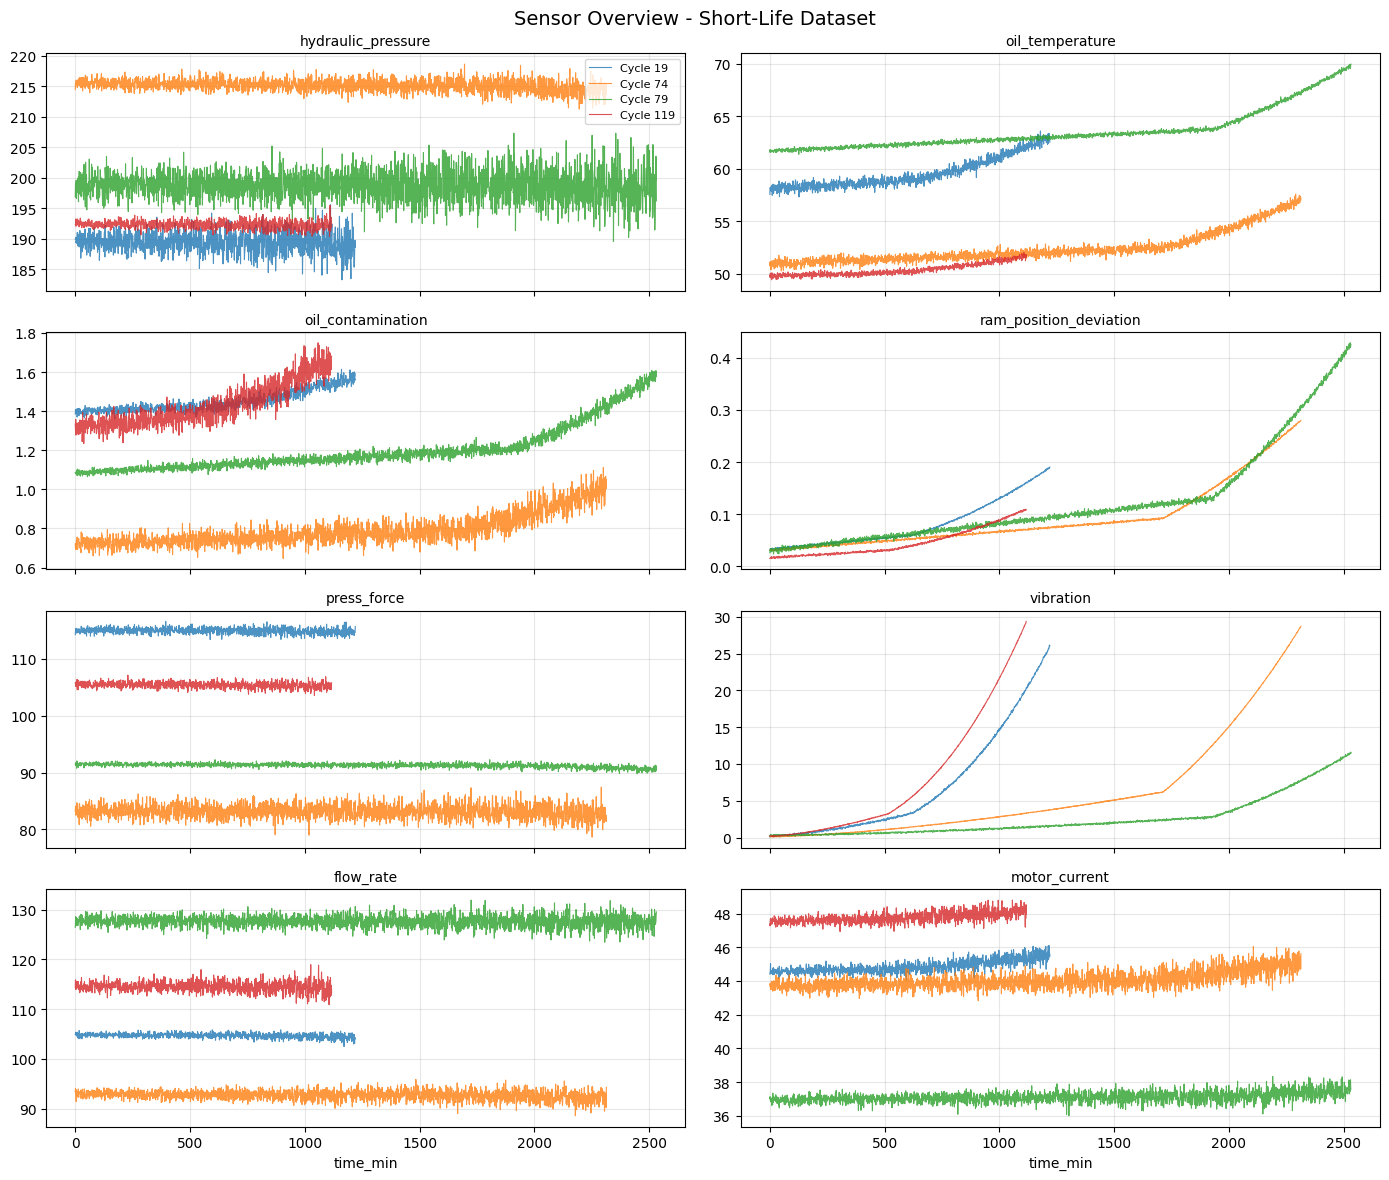


Sampling Long-Life dataset for visualization...
Selected cycles for Long-Life Dataset (Sampled): [4, 38, 40, 47]


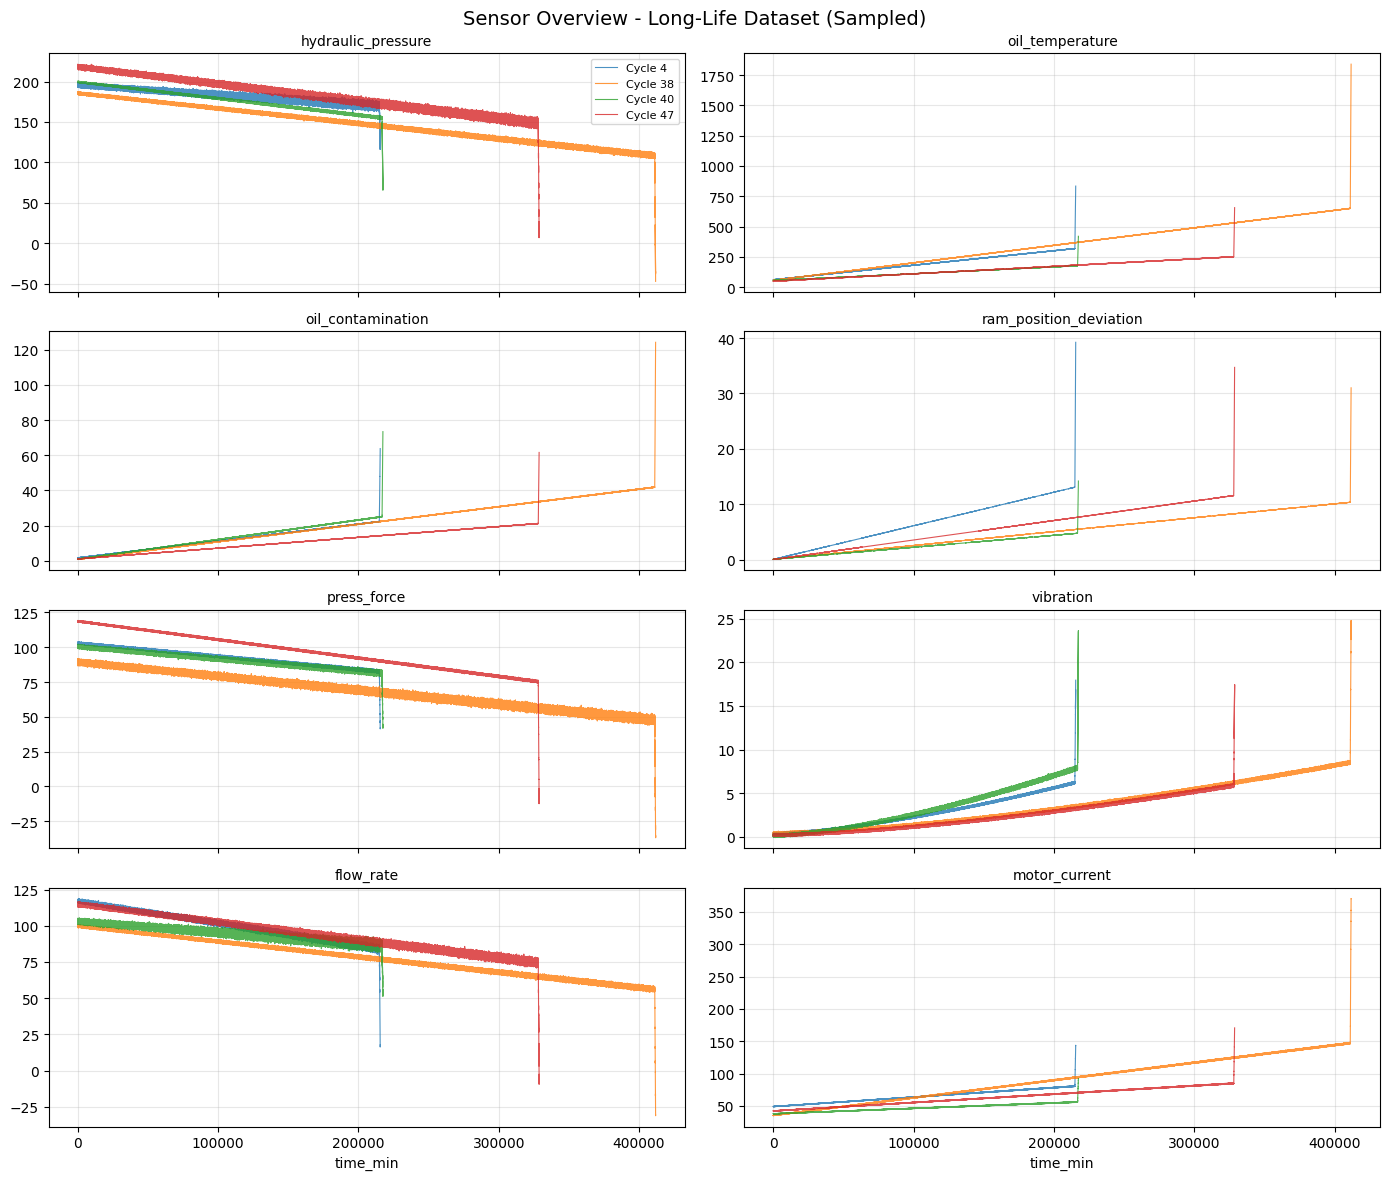


----------------------------------------------------------------------
EDA COMPLETE
----------------------------------------------------------------------


In [ ]:
# 2/ Exploratory Data Analysis - Sensor Overview
print_header("2/ EXPLORATORY DATA ANALYSIS")

def plot_sensor_overview(dataframe, dataset_name):
    """Plot sensor trends for selected cycles."""
    
    # Select 4 random cycles for visualization
    np.random.seed(42)
    all_cycles = sorted(dataframe['cycle_id'].unique())
    selected_cycles = sorted(np.random.choice(all_cycles, size=min(4, len(all_cycles)), replace=False))
    
    print(f"Selected cycles for {dataset_name}: {selected_cycles}")
    
    # Create subplot grid
    fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
    axes = axes.flatten()
    
    colors = plt.cm.tab10.colors[:4]
    
    for sensor_idx, sensor_name in enumerate(SENSOR_COLUMNS):
        ax = axes[sensor_idx]
        
        for cycle_idx, cycle_id in enumerate(selected_cycles):
            cycle_data = dataframe[dataframe['cycle_id'] == cycle_id].sort_values('time_min')
            ax.plot(
                    cycle_data['time_min'], 
                    cycle_data[sensor_name], 
                    label=f'Cycle {cycle_id}',
                    color=colors[cycle_idx],
                    linewidth=0.8,
                    alpha=0.8
                )
        
        ax.set_title(sensor_name, fontsize=10)
        ax.grid(alpha=0.3)
    
    # Add legend to first subplot
    axes[0].legend(loc='upper right', fontsize=8)
    
    # Set common x-label
    for ax in axes[-2:]:
        ax.set_xlabel('time_min')
    
    fig.suptitle(f'Sensor Overview - {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot for Short-Life (smaller dataset, faster to plot)
plot_sensor_overview(df_short_life, "Short-Life Dataset")

# Sample Long-Life for faster plotting
print("\nSampling Long-Life dataset for visualization...")
sample_cycles = np.random.choice(df_long_life['cycle_id'].unique(), size=4, replace=False)
df_long_sample = df_long_life[df_long_life['cycle_id'].isin(sample_cycles)]
plot_sensor_overview(df_long_sample, "Long-Life Dataset (Sampled)")

# Clean up sample
del df_long_sample
gc.collect()

print_footer("EDA COMPLETE")

### 2A) Additional EDA: RUL, Correlation & Distributions


2A/ CORRELATION ANALYSIS
Short-Life Dataset Correlations:


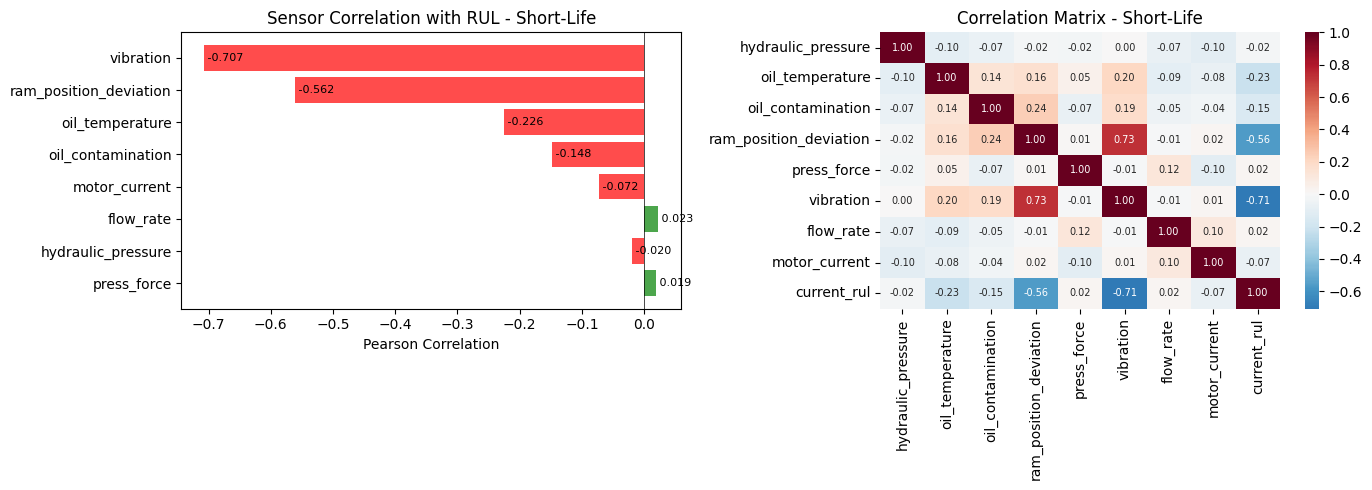

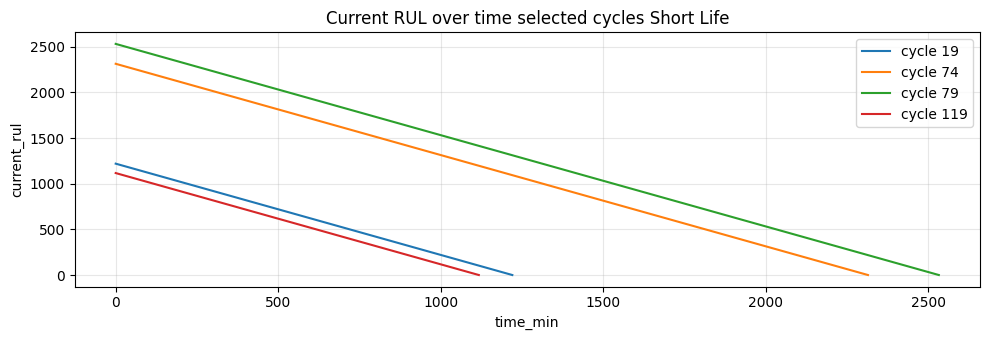


Long-Life Dataset Correlations (sampled):


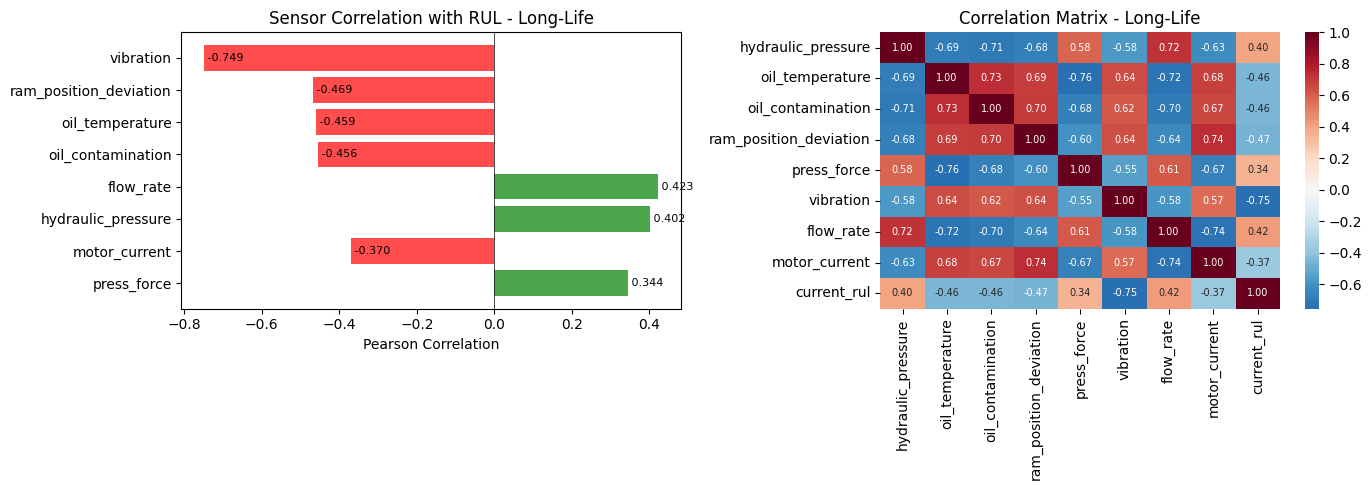

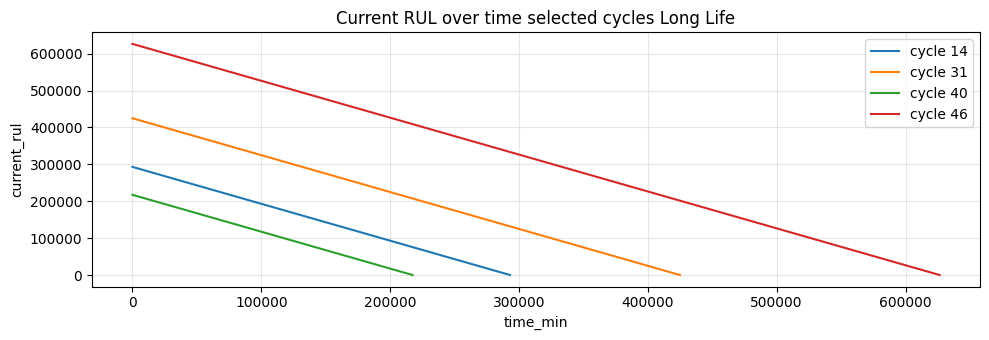


----------------------------------------------------------------------
CORRELATION ANALYSIS COMPLETE
----------------------------------------------------------------------


In [ ]:
# 2A/ Correlation Analysis
print_header("2A/ CORRELATION ANALYSIS")

SENSOR_COLUMNS = [
                    'hydraulic_pressure', 'oil_temperature', 'oil_contamination',
                    'ram_position_deviation', 'press_force', 'vibration',
                    'flow_rate', 'motor_current'
                ]


def plot_correlation_analysis(dataframe, dataset_name, sample_size=50000):
    """Plot correlation between sensors and RUL."""
    
    # Sample for memory efficiency
    if len(dataframe) > sample_size:
        df_sample = dataframe.sample(n=sample_size, random_state=42)
    else:
        df_sample = dataframe
    
    # Columns for correlation
    correlation_columns = SENSOR_COLUMNS + ['current_rul']
    
    # Calculate correlation matrix
    correlation_matrix = df_sample[correlation_columns].corr()
    
    # Extract RUL correlations
    rul_correlations = correlation_matrix['current_rul'].drop('current_rul')
    rul_correlations_sorted = rul_correlations.reindex(rul_correlations.abs().sort_values().index)
    
    # Plot correlation bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart of RUL correlations
    ax1 = axes[0]
    colors = ['green' if x > 0 else 'red' for x in rul_correlations_sorted.values]
    ax1.barh(rul_correlations_sorted.index, rul_correlations_sorted.values, color=colors, alpha=0.7)
    ax1.set_xlabel('Pearson Correlation')
    ax1.set_title(f'Sensor Correlation with RUL - {dataset_name}')
    ax1.axvline(x=0, color='black', linewidth=0.5)
    
    for i, (sensor, corr) in enumerate(rul_correlations_sorted.items()):
        ax1.text(corr, i, f' {corr:.3f}', va='center', fontsize=8)
    
    # Heatmap
    ax2 = axes[1]
    sns.heatmap(
                    correlation_matrix, 
                    annot=True, 
                    fmt='.2f', 
                    cmap='RdBu_r', 
                    center=0,
                    ax=ax2,
                    annot_kws={'size': 7}
                )
    ax2.set_title(f'Correlation Matrix - {dataset_name}')
    
    plt.tight_layout()
    plt.show()
    
    return rul_correlations_sorted

def additional_eda(dataframe_input, title_suffix=""):
    if not isinstance(dataframe_input, pl.DataFrame):
        dataframe_polars = pl.from_pandas(dataframe_input)
    else:
        dataframe_polars = dataframe_input

    available_sensors = [sensor_name for sensor_name in SENSOR_COLUMNS if sensor_name in dataframe_polars.columns]

    if not available_sensors:
        print(f"No sensor columns available for 2A EDA {title_suffix}")
        return

    np.random.seed(42)
    unique_cycle_ids = sorted(dataframe_polars.get_column("cycle_id").unique().to_list())
    number_of_cycles = min(4, len(unique_cycle_ids))
    selected_cycle_ids = sorted(np.random.choice(unique_cycle_ids, size=number_of_cycles, replace=False))

    plt.figure(figsize=(10, 3.5))
    for cycle_id in selected_cycle_ids:
        cycle_subset = dataframe_polars.filter(pl.col("cycle_id") == cycle_id).sort("time_min")
        plt.plot(
                    cycle_subset.get_column("time_min").to_numpy(),
                    cycle_subset.get_column("current_rul").to_numpy(),
                    label=f'cycle {cycle_id}',
                    linewidth=1.5
                )
    plt.xlabel('time_min')
    plt.ylabel('current_rul')
    plt.title(f'Current RUL over time selected cycles {title_suffix}')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



# Analyze Short-Life dataset
print("Short-Life Dataset Correlations:")
short_correlations = plot_correlation_analysis(df_short_life, "Short-Life")
additional_eda(df_short_life, title_suffix="Short Life")

# Analyze Long-Life dataset (sampled)
print("\nLong-Life Dataset Correlations (sampled):")
long_correlations = plot_correlation_analysis(df_long_life, "Long-Life")
additional_eda(df_long_life, title_suffix="Long Life")

print_footer("CORRELATION ANALYSIS COMPLETE")

### 2B) Cycle-to-cycle comparison (start vs end)

2B/ CYCLE COMPARISONS - start vs end summaries and plots

Example start/end table (Short Life) (first 8 cycles - sample sensors):


,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,211.502,63.126,1.760,0.020,211.897,70.568,2.142,0.198
1,2,210.962,51.107,1.824,0.012,208.208,59.114,2.490,0.620
2,3,199.403,50.521,1.613,0.031,199.586,53.102,1.763,0.169
3,4,188.738,46.780,0.596,0.033,187.406,50.471,0.858,0.318
4,5,186.534,59.795,1.559,0.014,186.325,63.271,1.912,0.122
5,6,189.367,55.939,1.358,0.015,185.713,66.841,1.861,0.600
6,7,216.989,64.046,0.996,0.047,218.402,65.510,1.068,0.190
7,8,213.039,51.410,1.915,0.048,209.445,53.095,2.019,0.207



Delta summary (Short Life) (end - start):
                              count    mean    std     min     25%     50%     75%     max
hydraulic_pressure_delta      150.0  -0.773  2.140  -8.932  -1.975  -0.573   0.455   5.327
oil_temperature_delta         150.0   5.122  2.572   0.971   2.952   4.934   6.749  12.996
oil_contamination_delta       150.0   0.410  0.217   0.005   0.259   0.380   0.540   1.014
ram_position_deviation_delta  150.0   0.270  0.155   0.059   0.145   0.247   0.380   0.704
press_force_delta             150.0  -0.444  1.178  -3.398  -1.070  -0.474   0.249   3.159
vibration_delta               150.0  20.704  5.379  10.873  16.215  20.799  25.762  29.402
flow_rate_delta               150.0  -0.526  1.102  -3.953  -1.313  -0.571   0.301   3.114
motor_current_delta           150.0   0.973  0.787  -0.916   0.462   0.830   1.386   3.401


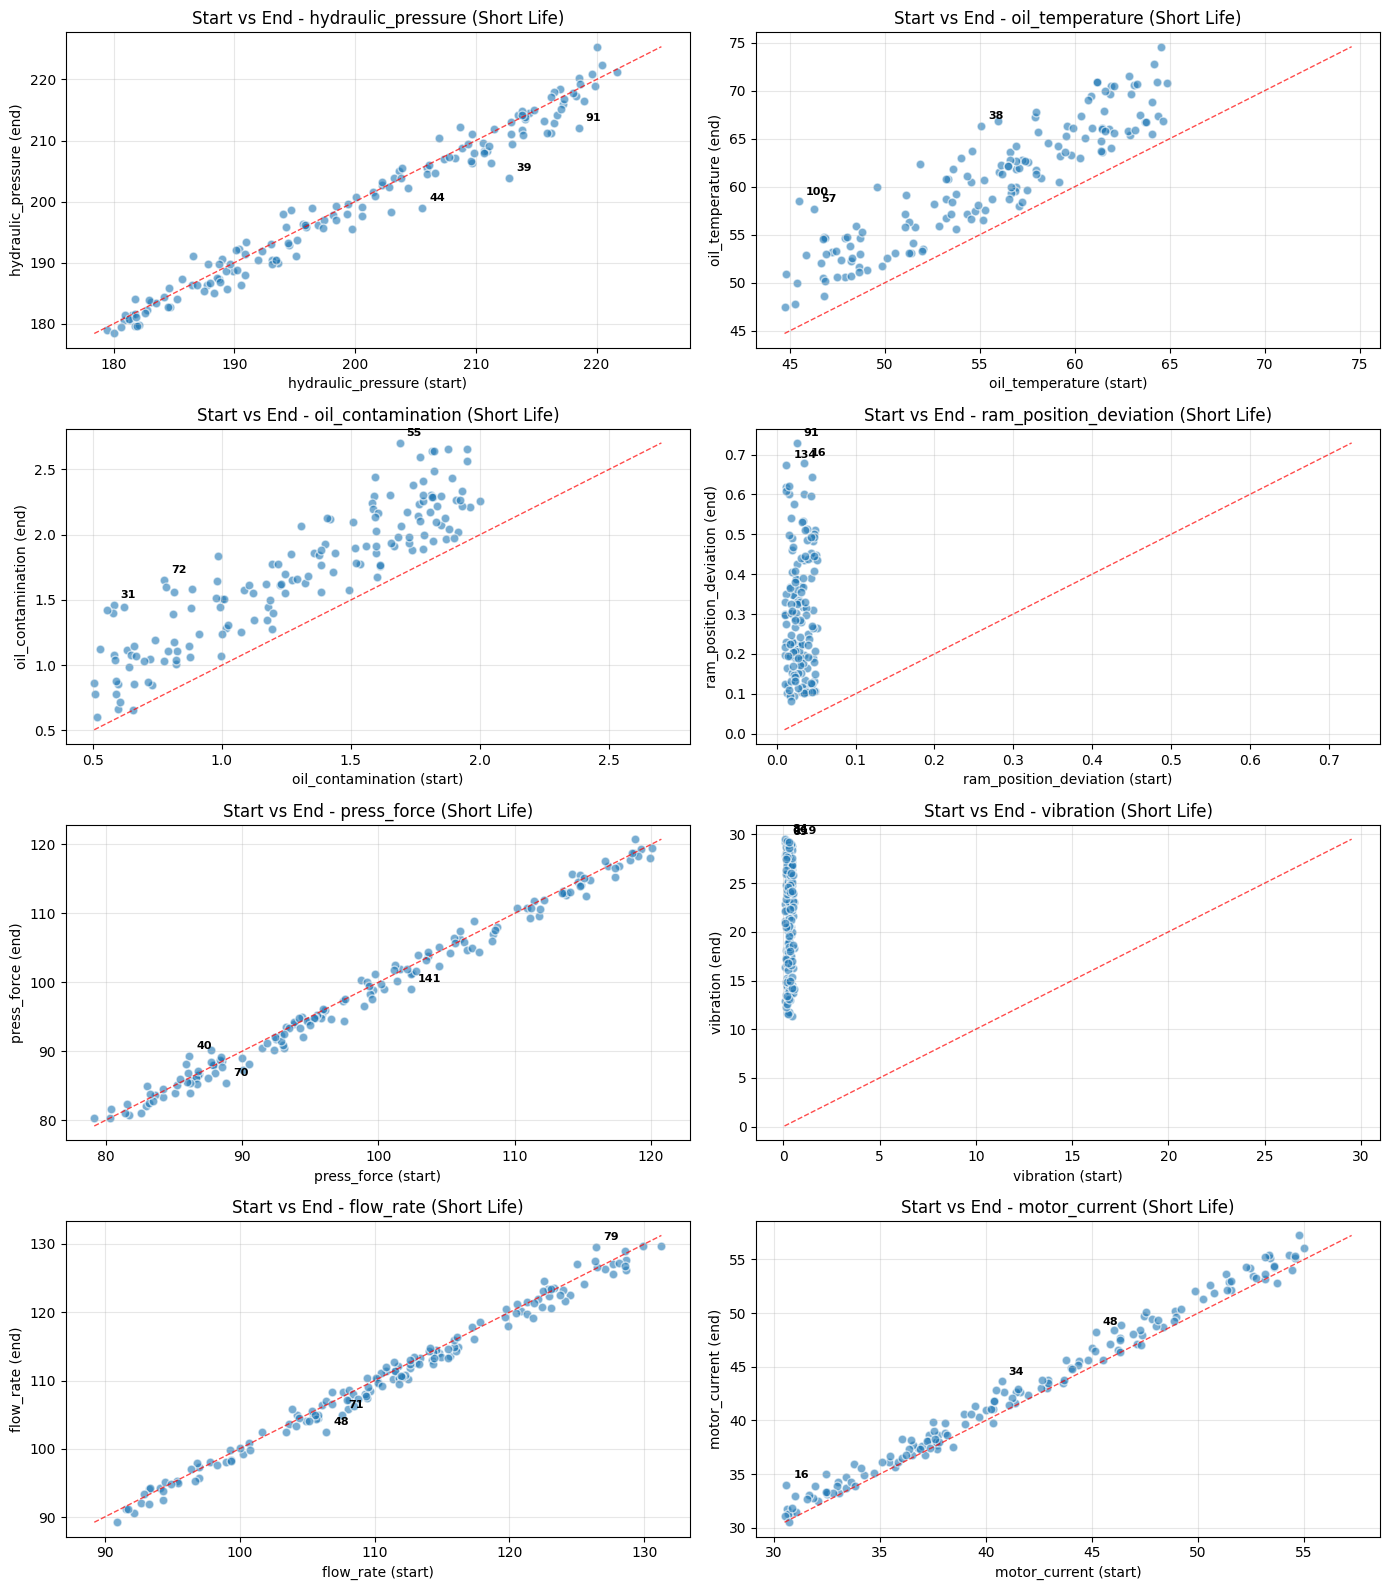


Top Extremes per Sensor ((Short Life))

Largest increase in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       85             220.047                 225.374                     5.327
      136             186.565                 191.134                     4.569
      146             194.001                 197.898                     3.897
Largest decrease in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       39             212.769                 203.837                    -8.932
       44             205.568                 198.980                    -6.588
       91             218.515                 212.053                    -6.462

Largest increase in oil_temperature:
 cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
      100           45.470               58.466                 12.996
       57           46.298               57.726            

,cycle_id,hydraulic_pressure,oil_temperature,oil_contamination,ram_position_deviation,hydraulic_pressure_end,oil_temperature_end,oil_contamination_end,ram_position_deviation_end
0,1,197.155,47.083,1.701,0.026,76.026,815.075,27.831,39.387
1,2,200.493,46.089,1.275,0.042,-17.572,2104.880,130.121,35.602
2,3,183.925,58.880,1.062,0.035,-29.354,809.810,67.345,101.169
3,4,195.515,61.594,1.792,0.033,116.276,833.556,63.776,39.232
4,5,182.823,45.423,0.665,0.027,-39.863,1080.655,121.821,51.855
5,6,209.147,63.140,1.154,0.015,-19.490,2231.159,113.088,103.229
6,7,206.900,54.919,0.776,0.036,100.395,707.657,40.900,17.996
7,8,216.399,46.274,0.831,0.037,76.221,1009.510,76.222,27.820



Delta summary (Long Life) (end - start):
                              count      mean      std      min      25%      50%       75%       max
hydraulic_pressure_delta       50.0  -197.046   99.126 -456.517 -232.122 -169.893  -123.026   -62.638
oil_temperature_delta          50.0  1195.456  641.823  364.759  667.375  974.935  1736.573  2607.270
oil_contamination_delta        50.0    94.513   51.005   20.425   54.925   88.498   124.743   231.771
ram_position_deviation_delta   50.0    55.777   30.065   14.138   33.386   45.012    69.523   143.563
press_force_delta              50.0  -117.466   62.075 -281.320 -154.351 -100.512   -71.530   -22.006
vibration_delta                50.0    19.555    5.159   10.891   15.551   18.595    23.837    28.260
flow_rate_delta                50.0  -146.088   80.525 -338.074 -204.721 -124.104   -87.200   -29.868
motor_current_delta            50.0   226.333  138.996   54.486  131.801  176.131   316.150   600.803


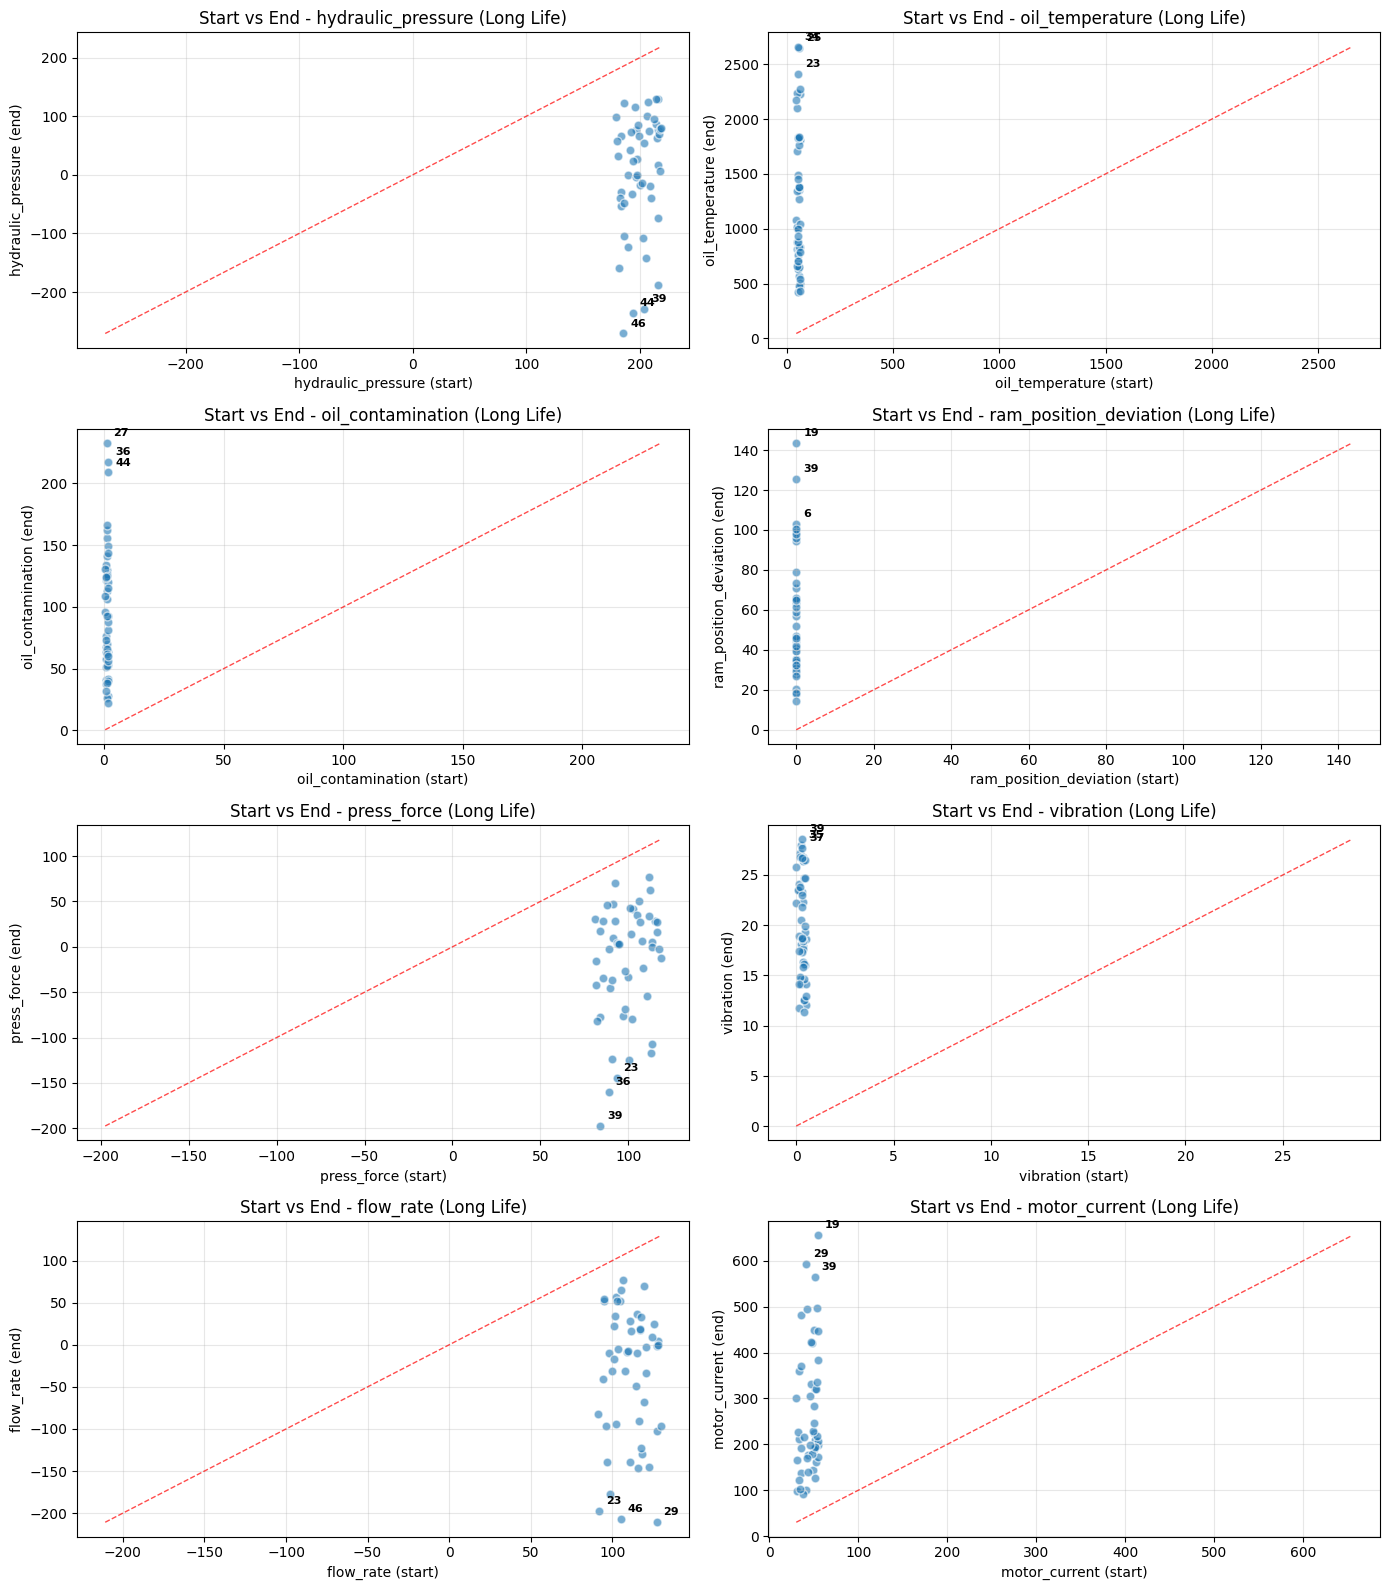


Top Extremes per Sensor ((Long Life))

Largest increase in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       30             185.887                 123.249                   -62.638
        4             195.515                 116.276                   -79.240
       41             179.281                  99.679                   -79.602
Largest decrease in hydraulic_pressure:
 cycle_id  hydraulic_pressure  hydraulic_pressure_end  hydraulic_pressure_delta
       46             185.751                -270.766                  -456.517
       39             204.011                -229.022                  -433.033
       44             193.754                -235.892                  -429.647

Largest increase in oil_temperature:
 cycle_id  oil_temperature  oil_temperature_end  oil_temperature_delta
       34           52.167             2659.437               2607.270
       25           58.168             2649.920             

In [ ]:
# 2B/ Cycle Comparisons - Start vs End Summaries and Plots
print("2B/ CYCLE COMPARISONS - start vs end summaries and plots")

def cycle_comparison(df_raw, title_suffix=""):
   
    # Determine sensor list
    if 'SENSOR_COLUMNS' in globals():
        sensors = SENSOR_COLUMNS
    else:
        sensors = [
                    "hydraulic_pressure", "oil_temperature", "oil_contamination",
                    "ram_position_deviation", "press_force", "vibration",
                    "flow_rate", "motor_current"
                ]

    # polars or pandas input
    try:
        is_pl = isinstance(df_raw, pl.DataFrame)
    except Exception:
        is_pl = False

    if is_pl:
        df_sorted = df_raw.sort(["cycle_id", "time_min"])
        firsts = df_sorted.groupby("cycle_id").first()
        lasts = df_sorted.groupby("cycle_id").last()
        # select only needed sensor cols that exist
        available_sensors = [s for s in sensors if s in df_raw.columns]
        cols_start = ["cycle_id"] + available_sensors
        cols_end = ["cycle_id"] + available_sensors
        start_end = firsts.select(cols_start).join(lasts.select(cols_end), on="cycle_id", how="inner", suffix="_end")
        # compute deltas and pct change using polars then convert to pandas for plotting
        for s in available_sensors:
            start_end = start_end.with_columns(
                                                    (pl.col(f"{s}_end") - pl.col(s)).alias(f"{s}_delta")
                                                ).with_columns(
                                                                ( (pl.col(f"{s}_delta") / pl.when(pl.col(s) == 0).then(None).otherwise(pl.col(s))) * 100 ).alias(f"{s}_pct_change")
                                                )
        start_end_pd = start_end.to_pandas()
    else:
        # pandas path
        df_sorted = df_raw.sort_values(["cycle_id", "time_min"])
        available_sensors = [s for s in sensors if s in df_raw.columns]
        if not available_sensors:
            print(f"No sensors found to compare {title_suffix}")
            return
        firsts = df_sorted.groupby("cycle_id").first().reset_index()
        lasts = df_sorted.groupby("cycle_id").last().reset_index()

        # build lasts_end by renaming only sensor columns
        lasts_end = lasts[["cycle_id"] + available_sensors].copy()
        lasts_end = lasts_end.rename(columns={s: f"{s}_end" for s in available_sensors})

        start_end_pd = pd.merge(
                                    firsts[["cycle_id"] + available_sensors],
                                    lasts_end,
                                    on="cycle_id",
                                    how="inner"
                                )

        # compute deltas and percent changes
        for s in available_sensors:
            start_end_pd[f"{s}_delta"] = start_end_pd[f"{s}_end"] - start_end_pd[s]
            start_end_pd[f"{s}_pct_change"] = start_end_pd[f"{s}_delta"] / start_end_pd[s].replace(0, np.nan) * 100.0


    # Basic display
    cols_show = ["cycle_id"] + available_sensors[:4] + [f"{s}_end" for s in available_sensors[:4]]
    print(f"\nExample start/end table {title_suffix} (first 8 cycles - sample sensors):")
    display(start_end_pd[cols_show].head(8))

    delta_cols = [f"{s}_delta" for s in available_sensors]
    print(f"\nDelta summary {title_suffix} (end - start):")
    print(start_end_pd[delta_cols].describe().T)

    # Plotting: dynamic grid (2 columns)
    n = len(available_sensors)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, s in enumerate(available_sensors):
        ax = axes[i]
        x = start_end_pd[s]
        y = start_end_pd[f"{s}_end"]
        ax.scatter(x, y, alpha=0.6, edgecolors="w", s=40)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, "--", color="red", linewidth=1, alpha=0.7)
        ax.set_xlabel(f"{s} (start)")
        ax.set_ylabel(f"{s} (end)")
        ax.set_title(f"Start vs End - {s} {title_suffix}")
        ax.grid(alpha=0.3)

        # annotate top 3 absolute deltas
        top3_idx = start_end_pd[f"{s}_delta"].abs().nlargest(3).index
        for idx in top3_idx:
            row = start_end_pd.loc[idx]
            cid = int(row["cycle_id"])
            ax.annotate(
                            cid,
                            (row[s], row[f"{s}_end"]),
                            textcoords="offset points",
                            xytext=(5, 5),
                            fontsize=8,
                            fontweight="bold"
                        )

    # turn off unused axes
    for j in range(n, rows * cols):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    # Print top extremes for first three sensors
    print(f"\nTop Extremes per Sensor ({title_suffix})")
    for s in available_sensors[:3]:
        print(f"\nLargest increase in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nlargest(3, f"{s}_delta").to_string(index=False))
        print(f"Largest decrease in {s}:")
        print(start_end_pd[["cycle_id", s, f"{s}_end", f"{s}_delta"]].nsmallest(3, f"{s}_delta").to_string(index=False))

    print(f"\n{'='*50}\nExplanatory Data Analysis COMPLETED {title_suffix}\n{'='*50}")


cycle_comparison(df_short_life, title_suffix="(Short Life)")
cycle_comparison(df_long_life, title_suffix="(Long Life)")

## 3) Train / Validation / Test split

In [ ]:
# 3/ Train / Validation / Test Split
print_header("3/ DATASET SPLIT - Cycle-based")

def split_by_cycles(dataframe, train_ratio=0.7, val_ratio=0.15, random_seed=42):
   
    # Get all unique cycles
    all_cycles = sorted(dataframe['cycle_id'].unique())
    total_cycles = len(all_cycles)
    
    # Shuffle cycles deterministically
    rng = np.random.default_rng(seed=random_seed)
    rng.shuffle(all_cycles)
    
    # Calculate split sizes
    n_train = int(total_cycles * train_ratio)
    n_val = int(total_cycles * val_ratio)
    n_test = total_cycles - n_train - n_val
    
    # Split cycles
    train_cycles = all_cycles[:n_train]
    val_cycles = all_cycles[n_train:n_train + n_val]
    test_cycles = all_cycles[n_train + n_val:]
    
    # Create dataframes
    df_train = dataframe[dataframe['cycle_id'].isin(train_cycles)].copy()
    df_val = dataframe[dataframe['cycle_id'].isin(val_cycles)].copy()
    df_test = dataframe[dataframe['cycle_id'].isin(test_cycles)].copy()
    
    # Print split info
    print(f"Total cycles: {total_cycles}")
    print(f"Train cycles ({len(train_cycles)}): {train_cycles[:5]}...")
    print(f"Val cycles ({len(val_cycles)}): {val_cycles[:5]}...")
    print(f"Test cycles ({len(test_cycles)}): {test_cycles[:5]}...")
    print(f"\nRow counts:")
    print(f"  Train: {len(df_train):,} rows")
    print(f"  Val: {len(df_val):,} rows")
    print(f"  Test: {len(df_test):,} rows")
    
    # Verify no overlap
    assert set(train_cycles).isdisjoint(val_cycles), "Train and Val cycles overlap!"
    assert set(train_cycles).isdisjoint(test_cycles), "Train and Test cycles overlap!"
    assert set(val_cycles).isdisjoint(test_cycles), "Val and Test cycles overlap!"
    
    return df_train, df_val, df_test

# Split Short-Life dataset
print("--- Short-Life Dataset Split")
df_train_short, df_val_short, df_test_short = split_by_cycles(df_short_life)

print("\n" + "=" * 70)

# Split Long-Life dataset
print("\n--- Long-Life Dataset Split")
df_train_long, df_val_long, df_test_long = split_by_cycles(df_long_life)

# Free original dataframes to save memory
print("\nFreeing original dataframes...")
del df_long_life, df_short_life
gc.collect()

print_footer("DATA SPLIT COMPLETE")


3/ DATASET SPLIT - Cycle-based (Leakage-Free)
--- Short-Life Dataset Split
Total cycles: 150
Train cycles (105): [71, 80, 135, 4, 124]...
Val cycles (22): [33, 62, 58, 116, 24]...
Test cycles (23): [68, 35, 31, 59, 36]...

Row counts:
  Train: 183,656 rows
  Val: 37,951 rows
  Test: 40,085 rows


--- Long-Life Dataset Split
Total cycles: 50
Train cycles (35): [6, 26, 21, 50, 40]...
Val cycles (7): [7, 12, 23, 20, 36]...
Test cycles (8): [15, 49, 3, 37, 34]...

Row counts:
  Train: 13,626,714 rows
  Val: 2,726,359 rows
  Test: 3,398,614 rows

Freeing original dataframes...

----------------------------------------------------------------------
DATA SPLIT COMPLETE
----------------------------------------------------------------------



3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions
Dataset         : (Short Life)
Selected sensor : vibration
Train cycles    : 105
Val cycles      : 22
Test cycles     : 23


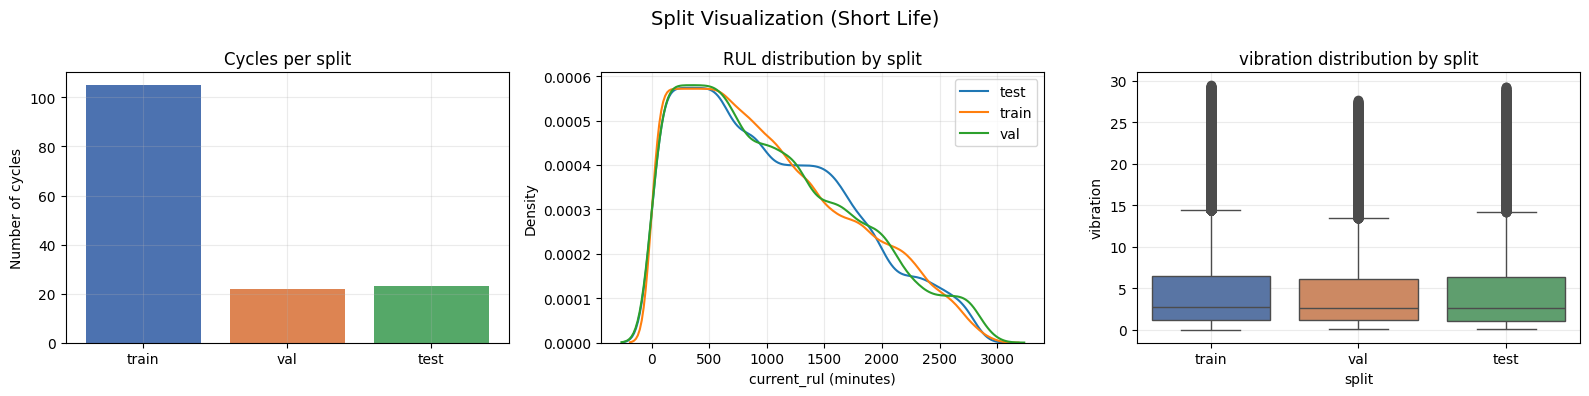


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Short Life)
----------------------------------------------------------------------
Dataset         : (Long Life)
Selected sensor : vibration
Train cycles    : 35
Val cycles      : 7
Test cycles     : 8


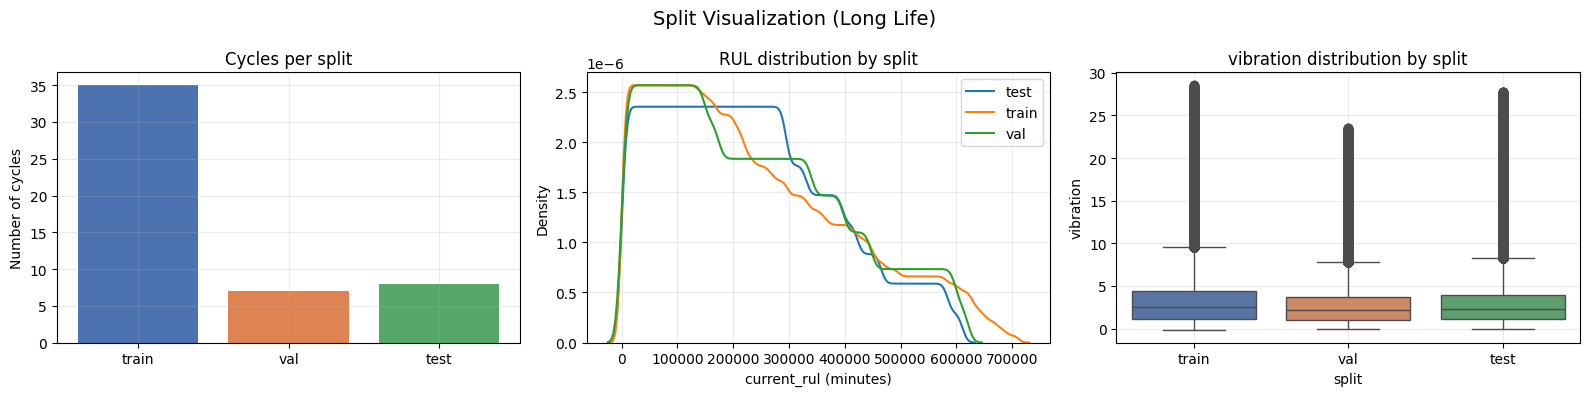


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Long Life)
----------------------------------------------------------------------


In [9]:
# 3A/ Split Visualization - cycles, RUL & sensor distributions
print_header("3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions")

def visualize_splits(df_train, df_val, df_test, title_suffix=""):
    # Ensure RUL is present
    assert 'current_rul' in df_train.columns, "current_rul missing in selected split dataframe"

    # Choose a sensor to visualize (prefer 'vibration' or fallback)
    preferred = 'vibration'
    if preferred in df_train.columns:
        sensor_col = preferred
    else:
        exclude = {'cycle_id', 'time_min', 'timestamp', 'total_rul', 'current_rul'}
        numeric = get_numeric_sensor_cols(df_train, exclude)
        sensor_col = numeric[0] if len(numeric) > 0 else None

    assert sensor_col is not None, "No suitable sensor or feature column found for visualization"

    # Prepare combined dataframe for easy plotting
    def tag_split(df, name):
        d = df[[sensor_col, 'current_rul', 'cycle_id']].copy()
        d['split'] = name
        return d

    plot_df = pd.concat([
                            tag_split(df_train, 'train'),
                            tag_split(df_val, 'val'),
                            tag_split(df_test, 'test')
                        ], ignore_index=True)

    print_kv([
                ('Dataset', title_suffix),
                ('Selected sensor', sensor_col),
                ('Train cycles', df_train['cycle_id'].nunique()),
                ('Val cycles', df_val['cycle_id'].nunique()),
                ('Test cycles', df_test['cycle_id'].nunique())
            ])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Cycles per split
    counts = [df_train['cycle_id'].nunique(),
              df_val['cycle_id'].nunique(),
              df_test['cycle_id'].nunique()]
    axes[0].bar(['train', 'val', 'test'], counts,
                color=['#4c72b0', '#dd8452', '#55a868'])
    axes[0].set_title('Cycles per split')
    axes[0].set_ylabel('Number of cycles')
    axes[0].grid(alpha=0.25)

    # RUL distribution (overlayed KDEs)
    for name, grp in plot_df.groupby('split'):
        sns.kdeplot(grp['current_rul'], ax=axes[1], label=name, fill=False)
    axes[1].set_title('RUL distribution by split')
    axes[1].set_xlabel('current_rul (minutes)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    # Sensor distribution (boxplot)
    sns.boxplot(x='split', y=sensor_col, data=plot_df,
                ax=axes[2], palette=['#4c72b0', '#dd8452', '#55a868'])
    axes[2].set_title(f'{sensor_col} distribution by split')
    axes[2].grid(alpha=0.25)

    plt.suptitle(f"Split Visualization {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print_footer(f"SPLIT VISUALIZATION COMPLETE {title_suffix}")


# Run for both datasets
visualize_splits(df_train_short, df_val_short, df_test_short, title_suffix="(Short Life)")
visualize_splits(df_train_long, df_val_long, df_test_long, title_suffix="(Long Life)")

## 4) Feature Engineering

In [ ]:
# 4/ Feature Engineering - Causal & Critical-Aware
print_header("4/ FEATURE ENGINEERING - Causal & Critical-Aware")

def engineer_features_streaming(df, sensors=None, window_short=5, window_long=20):
    if sensors is None:
        sensors = SENSOR_COLUMNS

    if isinstance(df, pd.DataFrame):
        df_pl = pl.from_pandas(df).lazy()
    elif isinstance(df, pl.DataFrame):
        df_pl = df.lazy()
    else:
        raise TypeError("df must be pandas.DataFrame or polars.DataFrame")

    main_exprs = []
    for s in sensors:
        if s in df_pl.columns:
            main_exprs.extend([
                                pl.col(s).rolling_mean(window_short).over("cycle_id").alias(f"{s}_roll_mean_{window_short}"),
                                pl.col(s).rolling_mean(window_long).over("cycle_id").alias(f"{s}_roll_mean_{window_long}"),
                                pl.col(s).rolling_std(window_long).over("cycle_id").fill_null(0).alias(f"{s}_roll_std_{window_long}"),
                            ])

    df_pl = df_pl.with_columns(main_exprs)

    derived_exprs = []
    for s in sensors:
        if s in df_pl.columns:
            derived_exprs.append((pl.col(s) - pl.col(f"{s}_roll_mean_{window_long}")).alias(f"{s}_dev_long"))
            derived_exprs.append(pl.col(f"{s}_roll_mean_{window_long}").diff().over("cycle_id").fill_null(0).alias(f"{s}_slope_{window_long}"))

    if 'press_force' in df_pl.columns and 'hydraulic_pressure' in df_pl.columns:
        derived_exprs.append((pl.col('press_force') / pl.col('hydraulic_pressure')).fill_nan(1.0).clip(0, 10).alias('force_pressure_coupling'))
    else:
        derived_exprs.append(pl.lit(1.0).alias('force_pressure_coupling'))

    if 'vibration' in df_pl.columns:
        derived_exprs.append((pl.col('vibration').rolling_mean(window_short).over("cycle_id") ** 2).alias('vibration_energy'))

    if 'hydraulic_pressure_roll_std_20' in df_pl.columns:
        derived_exprs.append((1.0 / pl.col('hydraulic_pressure_roll_std_20').clip(1e-4)).log1p().alias('pressure_stability'))
    else:
        derived_exprs.append(pl.lit(0.0).alias('pressure_stability'))

    df_pl = df_pl.with_columns(derived_exprs)

    crit_exprs = []
    for s in ['vibration', 'oil_temperature', 'motor_current']:
        col = f"{s}_slope_{window_long}"
        if col in df_pl.columns:
            crit_exprs.append(pl.col(col).diff(5).over("cycle_id").fill_null(0).alias(f"{s}_acceleration"))
        else:
            crit_exprs.append(pl.lit(0.0).alias(f"{s}_acceleration"))

    for s in sensors:
        if s in df_pl.columns:
            short_std = pl.col(s).rolling_std(5).over("cycle_id")
            long_std = pl.col(f"{s}_roll_std_{window_long}")
            crit_exprs.append(pl.when((short_std - long_std) > 0).then(short_std - long_std).otherwise(0).fill_null(0).alias(f"{s}_volatility_surge"))

    def get_norm(col_name):
        if col_name not in df_pl.columns: return pl.lit(0.0)
        c = pl.col(col_name)
        return (c - c.min().over("cycle_id")) / (c.max().over("cycle_id") - c.min().over("cycle_id") + 1e-9)

    deg_idx = (get_norm('vibration') + get_norm('oil_temperature') + (1 - get_norm('hydraulic_pressure')) + get_norm('oil_contamination')) / 4.0
    crit_exprs.append(deg_idx.alias("degradation_index"))

    for s in ['vibration', 'motor_current']:
        if s in df_pl.columns:
            crit_exprs.append(pl.col(s).rolling_max(10).over("cycle_id").fill_null(0).alias(f"{s}_max_10"))
        else:
            crit_exprs.append(pl.lit(0.0).alias(f"{s}_max_10"))

    result = df_pl.with_columns(crit_exprs).collect().to_pandas().fillna(0)
    return result

def engineer_features(df):
    res = engineer_features_streaming(df)
    gc.collect()
    return res

print("\nProcessing SHORT LIFE Dataset...")
df_train_short = engineer_features(df_train_short)
df_val_short   = engineer_features(df_val_short)
df_test_short  = engineer_features(df_test_short)

print("\nProcessing LONG LIFE Dataset...")
df_train_long = engineer_features(df_train_long)
df_val_long   = engineer_features(df_val_long)
df_test_long  = engineer_features(df_test_long)

new_features = sorted(list(set(df_train_short.columns) - set(SENSOR_COLUMNS) - {'cycle_id', 'time_min', 'RUL'}))

print("\nFeature engineering summary:")
print(f"  New features created: {len(new_features)}")
print(f"  Short Life Train: {df_train_short.shape} | Long Life Train: {df_train_long.shape}")
print(f"  Sample features: {new_features[:5]}")

print_footer("FEATURE ENGINEERING COMPLETE")


4/ FEATURE ENGINEERING - Causal & Critical-Aware

Processing SHORT LIFE Dataset...

Processing LONG LIFE Dataset...



Feature engineering summary:
  New features created: 59
  Short Life Train: (183656, 69) | Long Life Train: (13626714, 69)
  Sample features: ['current_rul', 'degradation_index', 'flow_rate_dev_long', 'flow_rate_roll_mean_20', 'flow_rate_roll_mean_5']

----------------------------------------------------------------------
FEATURE ENGINEERING COMPLETE
----------------------------------------------------------------------


## 5) Feature Selection

In [ ]:
# 5/ FEATURE SELECTION
print_header("5/ FEATURE SELECTION")

# Preconditions
assert 'df_train_short' in globals()
assert 'df_train_long' in globals()

TARGET_COL = 'current_rul'
EXCLUDE_COLS = {'cycle_id', 'time_min', 'timestamp', 'total_rul', TARGET_COL}

# Feature Candidate Discovery
feature_cols = [
                    c for c in df_train_short.columns
                    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_short[c])
                ]

print(f"Initial feature count: {len(feature_cols)}")

# Correlation Filtering (Short-Life ONLY)
print("\nCorrelation filtering (Short-Life only, downsampled)")

# aggressive but safe sampling
corr_sample = df_train_short.sample(
                                        n=min(100_000, len(df_train_short)),
                                        random_state=42
                                    )

X_corr = corr_sample[feature_cols].fillna(0)

corr_matrix = X_corr.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.95
to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]

features_after_corr = [f for f in feature_cols if f not in to_drop]

print(f"  Dropped due to correlation: {len(to_drop)}")
print(f"  Remaining features: {len(features_after_corr)}")

del corr_matrix, upper, X_corr, corr_sample

# Importance via XGBoost (Short-Life ONLY)
print("\nXGBoost importance (Short-Life only, stratified sample)")

# Stratified sampling by RUL regime
critical = df_train_short[df_train_short[TARGET_COL] <= 20]
mid = df_train_short[
                        (df_train_short[TARGET_COL] > 20) &
                        (df_train_short[TARGET_COL] <= 500)
                    ]
healthy = df_train_short[df_train_short[TARGET_COL] > 500]

imp_df = pd.concat([
                        critical,
                        mid.sample(n=min(len(mid), 40_000), random_state=42),
                        healthy.sample(n=min(len(healthy), 40_000), random_state=42)
                    ])

X_imp = imp_df[features_after_corr].fillna(0)
y_imp = imp_df[TARGET_COL]
y_imp_norm = y_imp / y_imp.max()

importances_accum = pd.Series(0.0, index=features_after_corr)

for seed in [41, 42, 43]:
    model = XGBRegressor(
                            n_estimators=150,
                            max_depth=5,
                            learning_rate=0.1,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            random_state=seed,
                            n_jobs=4,
                            verbosity=0
                        )
    model.fit(X_imp, y_imp_norm)
    importances_accum += model.feature_importances_

importances = (importances_accum / 3).sort_values(ascending=False)

print("\nTop 15 important features:")
for i, (f, v) in enumerate(importances.head(15).items(), 1):
    print(f"  {i:2d}. {f:35s} {v:.4f}")


# Final Feature Selection Logic
top_n = 20
cumulative = importances.cumsum()
selected_features = cumulative[cumulative <= 0.95].index.tolist()
selected_features = selected_features[:top_n]

print(f"\nSelected feature count: {len(selected_features)}")


# Persist Feature List
cache_file = os.path.join(save_path, "selected_hydraulic_press_features.json")
with open(cache_file, "w") as f:
    json.dump(selected_features, f, indent=4)

print(f"Saved feature list to: {cache_file}")


# Apply to Both Pipelines
print("\nApplying feature selection to datasets...")

# Short-Life
X_train_short = df_train_short[selected_features]
y_train_short = df_train_short[TARGET_COL]
X_val_short   = df_val_short[selected_features]
y_val_short   = df_val_short[TARGET_COL]
X_test_short  = df_test_short[selected_features]
y_test_short  = df_test_short[TARGET_COL]

# Long-Life
X_train_long = df_train_long[selected_features]
y_train_long = df_train_long[TARGET_COL]
X_val_long   = df_val_long[selected_features]
y_val_long   = df_val_long[TARGET_COL]
X_test_long  = df_test_long[selected_features]
y_test_long  = df_test_long[TARGET_COL]

# Sanity checks
assert len(selected_features) > 0
assert X_train_short.shape[1] == X_train_long.shape[1]


del importances_accum
gc.collect()

print("\nFinal Shapes:")
print(f"  Short-Life Train: {X_train_short.shape}")
print(f"  Long-Life Train : {X_train_long.shape}")

print_footer("FEATURE SELECTION COMPLETE")


5/ FEATURE SELECTION
Initial feature count: 65

Correlation filtering (Short-Life only, downsampled)
  Dropped due to correlation: 10
  Remaining features: 55

XGBoost importance (Short-Life only, stratified sample)

Top 15 important features:
   1. vibration_roll_std_20               0.2905
   2. degradation_index                   0.2130
   3. vibration                           0.0828
   4. vibration_energy                    0.0578
   5. vibration_dev_long                  0.0231
   6. hydraulic_pressure_dev_long         0.0218
   7. flow_rate_roll_mean_5               0.0191
   8. oil_temperature_roll_std_20         0.0181
   9. force_pressure_coupling             0.0167
  10. press_force_roll_mean_5             0.0162
  11. flow_rate_roll_mean_20              0.0157
  12. hydraulic_pressure_roll_mean_5      0.0145
  13. flow_rate                           0.0136
  14. motor_current_roll_mean_20          0.0120
  15. oil_temperature_roll_mean_5         0.0119

Selected feature co

## 6) Stage_0 Regime Detector

In [ ]:
# 6A/ Stage-0 Data Preparation
print_header("6A/ STAGE-0 DATA PREPARATION")

# Preconditions
assert 'df_train_long' in globals(), "df_train_long not found"
assert 'df_val_long' in globals(), "df_val_long not found"
assert 'df_test_long' in globals(), "df_test_long not found"
assert 'selected_features' in globals(), "selected_features not found"

# Stage-0 threshold: boundary between LONG_TERM and NEAR_TERM regimes
# NEAR_TERM starts at RUL <= 5000 minutes
STAGE0_THRESHOLD_MIN = 5000

# Target definition: 
# 0 = LONG_TERM (healthy), 
# 1 = NEAR_TERM (approaching critical)
def define_stage0_target(df, rul_col="current_rul"):
    return (df[rul_col] <= STAGE0_THRESHOLD_MIN).astype(int)

print("Defining Stage-0 targets...")
print(f"Stage-0 threshold: RUL <= {STAGE0_THRESHOLD_MIN} minutes -> NEAR_TERM (1)")

y_train_stage0 = define_stage0_target(df_train_long)
y_val_stage0   = define_stage0_target(df_val_long)
y_test_stage0  = define_stage0_target(df_test_long)

# Feature matrix
X_train_stage0 = df_train_long[selected_features]
X_val_stage0   = df_val_long[selected_features]
X_test_stage0  = df_test_long[selected_features]

print("Stage-0 dataset shapes:")
print(f"  Train X: {X_train_stage0.shape} | y: {y_train_stage0.shape}")
print(f"  Val   X: {X_val_stage0.shape}   | y: {y_val_stage0.shape}")
print(f"  Test  X: {X_test_stage0.shape}  | y: {y_test_stage0.shape}")

print("\nStage-0 class distribution (train):")
class_counts = y_train_stage0.value_counts()
print(f"  LONG_TERM (0): {class_counts.get(0, 0):,} samples ({class_counts.get(0, 0)/len(y_train_stage0)*100:.2f}%)")
print(f"  NEAR_TERM (1): {class_counts.get(1, 0):,} samples ({class_counts.get(1, 0)/len(y_train_stage0)*100:.2f}%)")

print_footer("STAGE-0 DATA PREPARATION COMPLETE")


6A/ STAGE-0 DATA PREPARATION
Defining Stage-0 targets...
Stage-0 threshold: RUL <= 5000 minutes -> NEAR_TERM (1)
Stage-0 dataset shapes:
  Train X: (13626714, 20) | y: (13626714,)
  Val   X: (2726359, 20)   | y: (2726359,)
  Test  X: (3398614, 20)  | y: (3398614,)

Stage-0 class distribution (train):
  LONG_TERM (0): 13,451,679 samples (98.72%)
  NEAR_TERM (1): 175,035 samples (1.28%)

----------------------------------------------------------------------
STAGE-0 DATA PREPARATION COMPLETE
----------------------------------------------------------------------


In [ ]:
# 6B/ Stage-0 Classifier Training
print_header("6B/ STAGE-0 CLASSIFIER TRAINING")

print("Training Stage-0 classifier...")
print("Purpose: Detect regime transition from LONG_TERM to NEAR_TERM")

stage0_model = XGBClassifier(
                                n_estimators=200,
                                max_depth=5,
                                learning_rate=0.05,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                objective="binary:logistic",
                                eval_metric="logloss",
                                random_state=42,
                                n_jobs=4,
                                verbosity=0
                            )

stage0_model.fit(
                    X_train_stage0,
                    y_train_stage0,
                    eval_set=[(X_val_stage0, y_val_stage0)],
                    verbose=False
                )

print("Evaluating Stage-0 classifier...")

y_val_pred_stage0 = stage0_model.predict(X_val_stage0)
y_val_prob_stage0 = stage0_model.predict_proba(X_val_stage0)[:, 1]

print("\nValidation classification report:")
print(classification_report(y_val_stage0, y_val_pred_stage0, digits=4,
                           target_names=["LONG_TERM", "NEAR_TERM"]))

val_auc_stage0 = roc_auc_score(y_val_stage0, y_val_prob_stage0)
print(f"Validation ROC AUC: {val_auc_stage0:.4f}")

# Save Model
joblib_path = os.path.join(save_path, "hydraulic_press_stage0_classifier.pkl")
joblib.dump(stage0_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

print_footer("STAGE-0 CLASSIFIER TRAINING COMPLETE")


6B/ STAGE-0 CLASSIFIER TRAINING
Training Stage-0 classifier...
Purpose: Detect regime transition from LONG_TERM to NEAR_TERM
Evaluating Stage-0 classifier...

Validation classification report:
              precision    recall  f1-score   support

   LONG_TERM     0.9968    0.9981    0.9974   2691352
   NEAR_TERM     0.8382    0.7519    0.7927     35007

    accuracy                         0.9950   2726359
   macro avg     0.9175    0.8750    0.8951   2726359
weighted avg     0.9947    0.9950    0.9948   2726359

Validation ROC AUC: 0.9985
Model saved (joblib): models_and_features/hydraulic_press/hydraulic_press_stage0_classifier.pkl

----------------------------------------------------------------------
STAGE-0 CLASSIFIER TRAINING COMPLETE
----------------------------------------------------------------------


In [ ]:
# 6C/ Stage-0 Filtering for Base Model
print_header("6C/ STAGE-0 FILTERING FOR BASE MODEL")

# Stage-0 filters samples for Base Model:
# Base Model should only see LONG_TERM samples
# Samples in NEAR_TERM but above critical threshold can still be used

print("Running Stage-0 inference on Long-Life dataset...")

train_stage0_prob = stage0_model.predict_proba(X_train_long)[:, 1]
val_stage0_prob   = stage0_model.predict_proba(X_val_long)[:, 1]
test_stage0_prob  = stage0_model.predict_proba(X_test_long)[:, 1]

STAGE0_PROB_THRESHOLD = 0.5
CRITICAL_RUL_THRESHOLD_MIN = 600

train_stage0_pred = (train_stage0_prob >= STAGE0_PROB_THRESHOLD).astype(int)
val_stage0_pred   = (val_stage0_prob   >= STAGE0_PROB_THRESHOLD).astype(int)
test_stage0_pred  = (test_stage0_prob  >= STAGE0_PROB_THRESHOLD).astype(int)

print("Filtering samples for Base Model eligibility...")
print(f"  Include: LONG_TERM samples (Stage-0 = 0)")
print(f"  Include: NEAR_TERM samples with RUL > {CRITICAL_RUL_THRESHOLD_MIN} min")
print(f"  Exclude: Critical samples (RUL <= {CRITICAL_RUL_THRESHOLD_MIN} min)")

# Base Model eligibility: LONG_TERM OR (NEAR_TERM AND not critical)
train_base_mask = (train_stage0_pred == 0) | (y_train_long > CRITICAL_RUL_THRESHOLD_MIN)
val_base_mask   = (val_stage0_pred   == 0) | (y_val_long   > CRITICAL_RUL_THRESHOLD_MIN)
test_base_mask  = (test_stage0_pred  == 0) | (y_test_long  > CRITICAL_RUL_THRESHOLD_MIN)

X_train_base_full = X_train_long[train_base_mask].copy()
X_val_base_full   = X_val_long[val_base_mask].copy()
X_test_base_full  = X_test_long[test_base_mask].copy()

y_train_base_min = y_train_long[train_base_mask].copy()
y_val_base_min   = y_val_long[val_base_mask].copy()
y_test_base_min  = y_test_long[test_base_mask].copy()

print("Selecting base model feature subset...")
print("  Excluding: acceleration, volatility, surge, energy, roll_std features")
print("  Reason: These features are designed for critical regime detection")

base_model_features = [
                        f for f in selected_features
                        if not any(k in f for k in [
                                                        "acceleration",
                                                        "volatility",
                                                        "surge",
                                                        "energy",
                                                        "roll_std"
                                                    ])
                    ]

assert len(base_model_features) > 0, "No base model features selected"

X_train_base = X_train_base_full[base_model_features]
X_val_base   = X_val_base_full[base_model_features]
X_test_base  = X_test_base_full[base_model_features]

print("Converting RUL from minutes to log-hours...")
print("  Transformation: log1p(RUL_min / 60)")
print("  Reason: Compress large RUL range for stable gradient descent")

y_train_base_hr = np.log1p(y_train_base_min / 60.0)
y_val_base_hr   = np.log1p(y_val_base_min / 60.0)
y_test_base_hr  = np.log1p(y_test_base_min / 60.0)

print("\nBase Model dataset shapes:")
print(f"  Train X: {X_train_base.shape} | y: {y_train_base_hr.shape}")
print(f"  Val   X: {X_val_base.shape} | y: {y_val_base_hr.shape}")
print(f"  Test  X: {X_test_base.shape} | y: {y_test_base_hr.shape}")

print("\nFiltering statistics:")
print(f"  Train: {train_base_mask.sum():,}/{len(train_base_mask):,} samples retained ({train_base_mask.mean()*100:.1f}%)")
print(f"  Val  : {val_base_mask.sum():,}/{len(val_base_mask):,} samples retained ({val_base_mask.mean()*100:.1f}%)")
print(f"  Test : {test_base_mask.sum():,}/{len(test_base_mask):,} samples retained ({test_base_mask.mean()*100:.1f}%)")

print("\nTarget range (log-hours):")
print(f"  Train: min={y_train_base_hr.min():.3f}, max={y_train_base_hr.max():.3f}")
print(f"  Val  : min={y_val_base_hr.min():.3f}, max={y_val_base_hr.max():.3f}")

print_footer("STAGE-0 FILTERING COMPLETE")


6C/ STAGE-0 FILTERING FOR BASE MODEL
Running Stage-0 inference on Long-Life dataset...
Filtering samples for Base Model eligibility...
  Include: LONG_TERM samples (Stage-0 = 0)
  Include: NEAR_TERM samples with RUL > 600 min
  Exclude: Critical samples (RUL <= 600 min)
Selecting base model feature subset...
  Excluding: acceleration, volatility, surge, energy, roll_std features
  Reason: These features are designed for critical regime detection
Converting RUL from minutes to log-hours...
  Transformation: log1p(RUL_min / 60)
  Reason: Compress large RUL range for stable gradient descent

Base Model dataset shapes:
  Train X: (13605679, 16) | y: (13605679,)
  Val   X: (2722155, 16) | y: (2722155,)
  Test  X: (3393806, 16) | y: (3393806,)

Filtering statistics:
  Train: 13,605,679/13,626,714 samples retained (99.8%)
  Val  : 2,722,155/2,726,359 samples retained (99.8%)
  Test : 3,393,806/3,398,614 samples retained (99.9%)

Target range (log-hours):
  Train: min=2.399, max=9.381
  Val  

## 7) Model Training (XGBoost)

In [15]:
# 7/ Base Model Training

print_header("7/ Base Model Training")

base_model = HistGradientBoostingRegressor(
                                            loss="absolute_error",
                                            max_depth=8,
                                            learning_rate=0.05,
                                            max_iter=300,
                                            random_state=42,
                                        )

print("Training Base Model...")
base_model.fit(X_train_base, y_train_base_hr)

print("Evaluating Base Model...")

val_pred_log = base_model.predict(X_val_base)
test_pred_log = base_model.predict(X_test_base)

val_pred_hr = np.expm1(val_pred_log)
test_pred_hr = np.expm1(test_pred_log)

y_val_true_hr = np.expm1(y_val_base_hr)
y_test_true_hr = np.expm1(y_test_base_hr)

val_mae = MAE(y_val_true_hr, val_pred_hr)
val_rmse = MSE(y_val_true_hr, val_pred_hr, squared=False)

test_mae = MAE(y_test_true_hr, test_pred_hr)
test_rmse = MSE(y_test_true_hr, test_pred_hr, squared=False)


print("Validation Metrics:")
print(f"  MAE  : {val_mae:.2f} hours")
print(f"  RMSE : {val_rmse:.2f} hours")

print("Test Metrics:")
print(f"  MAE  : {test_mae:.2f} hours")
print(f"  RMSE : {test_rmse:.2f} hours")

# save model
joblib_path = os.path.join(save_path, "hydraulic_press_base_model.pkl")
joblib.dump(base_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

print_footer("BASE MODEL TRAINING COMPLETE")



7/ Base Model Training
Training Base Model...
Evaluating Base Model...
Validation Metrics:
  MAE  : 676.78 hours
  RMSE : 1055.65 hours
Test Metrics:
  MAE  : 624.55 hours
  RMSE : 952.01 hours
Model saved (joblib): models_and_features/hydraulic_press/hydraulic_press_base_model.pkl

----------------------------------------------------------------------
BASE MODEL TRAINING COMPLETE
----------------------------------------------------------------------


In [16]:
# 7A/ Base Model Evaluation 
print_header("7A/ MODEL EVALUATION - Base Model Long-Life Analysis - HYDRAULIC PRESS")

# Convert back to minutes for evaluation
y_val_true_min = y_val_true_hr * 60.0
y_test_true_min = y_test_true_hr * 60.0
val_pred_min = val_pred_hr * 60.0
test_pred_min = test_pred_hr * 60.0


# OVERALL PERFORMANCE
print("\n=== OVERALL PERFORMANCE ===")

val_mae = MAE(y_val_true_min, val_pred_min)
val_rmse = R_MSE(y_val_true_min, val_pred_min)
val_r2   = r2_score(y_val_true_min, val_pred_min)

test_mae  = MAE(y_test_true_min, test_pred_min)
test_rmse = R_MSE(y_test_true_min, test_pred_min)
test_r2   = r2_score(y_test_true_min, test_pred_min)

print("\nVALIDATION (Long Life):")
print(f"   MAE: {val_mae:.2f} min")
print(f"  RMSE: {val_rmse:.2f}")
print(f"   R^2: {val_r2:.4f}")

print("\nTEST (Long Life):")
print(f"   MAE: {test_mae:.2f} min")
print(f"  RMSE: {test_rmse:.2f}")
print(f"   R^2: {test_r2:.4f}")

# RUL STRATIFIED ANALYSIS
print("\n=== RUL STRATIFIED ANALYSIS (TEST SET) ===")

bins = [
            (0, 100),
            (100, 1000),
            (1000, 10000),
            (10000, 100000),
            (100000, 500000)
        ]

labels = [
            "Near Critical",
            "Short Term",
            "Mid Term",
            "Long Term",
            "Initial Healthy"
        ]

print(f"{'Range':<18s} {'N':>8s} {'MAE':>12s} {'Error %':>10s}")
print("-" * 55)

for (low, high), label in zip(bins, labels):
    mask = ((y_test_true_min >= low) & (y_test_true_min < high)).to_numpy()
    if mask.sum() == 0:
        continue

    mae = MAE(y_test_true_min[mask], test_pred_min[mask])
    avg_true_rul = y_test_true_min[mask].mean()
    relative_error_percent = (mae / avg_true_rul) * 100 if avg_true_rul > 0 else 0.0

    print(f"{label:<18s} {mask.sum():8d} {mae:12.2f} {relative_error_percent:9.1f}%")

# CRITICAL REGION DIAGNOSTIC
print("\n=== CRITICAL REGION DIAGNOSTIC (RUL <= 100) ===")

critical_mask = (y_test_base_min <= 100).to_numpy()
critical_samples = critical_mask.sum()

if critical_samples > 0:
    assert len(critical_mask) == len(y_test_true_min) == len(test_pred_min)
    critical_mae = MAE(y_test_true_min[critical_mask], test_pred_min[critical_mask])
    print(f"  Samples found: {critical_samples}")
    print(f"  Base Model MAE in Critical Zone: {critical_mae:.2f} min")
else:
    print("  No critical samples found in test set.")

# BASE MODEL QUALITY CHECK
print("\n=== BASE MODEL QUALITY CHECK ===")

r2_requirement_passed = test_r2 >= 0.80

mid_long_life_mask = y_test_true_min > 1000
mid_long_life_mae = MAE(y_test_true_min[mid_long_life_mask], test_pred_min[mid_long_life_mask])
mid_long_life_avg = y_test_true_min[mid_long_life_mask].mean()
relative_error_mid_long = (mid_long_life_mae / mid_long_life_avg) * 100

relative_error_requirement_passed = relative_error_mid_long <= 20.0

print(f"  Overall R^2 >= 80%       : {'PASS' if r2_requirement_passed else 'FAIL'} ({test_r2 * 100:.1f}%)")
print(f"  Mid Long Term Err < 20%  : {'PASS' if relative_error_requirement_passed else 'FAIL'} ({relative_error_mid_long:.1f}%)")

print("\nFinal Decision: Base Model suitability is evaluated only for long term planning.")

print_footer("BASE MODEL EVALUATION COMPLETE")


7A/ MODEL EVALUATION - Base Model Long-Life Analysis - HYDRAULIC PRESS

=== OVERALL PERFORMANCE ===

VALIDATION (Long Life):
   MAE: 40606.69 min
  RMSE: 63338.98
   R^2: 0.8439

TEST (Long Life):
   MAE: 37472.77 min
  RMSE: 57120.63
   R^2: 0.8507

=== RUL STRATIFIED ANALYSIS (TEST SET) ===
Range                     N          MAE    Error %
-------------------------------------------------------
Short Term             3200      2388.87     298.4%
Mid Term              72000      1818.41      33.1%
Long Term            720000      8079.24      14.7%
Initial Healthy     2403333     43525.07      16.7%

=== CRITICAL REGION DIAGNOSTIC (RUL <= 100) ===
  No critical samples found in test set.

=== BASE MODEL QUALITY CHECK ===
  Overall R^2 >= 80%       : PASS (85.1%)
  Mid Long Term Err < 20%  : PASS (16.4%)

Final Decision: Base Model suitability is evaluated only for long term planning.

----------------------------------------------------------------------
BASE MODEL EVALUATION COMPL


7B/ VISUALIZATION - Feature Importance & Predictions vs True RUL
Top global importances (first 15):
vibration_roll_std_20             0.290
degradation_index                 0.213
vibration                         0.083
vibration_energy                  0.058
vibration_dev_long                0.023
hydraulic_pressure_dev_long       0.022
flow_rate_roll_mean_5             0.019
oil_temperature_roll_std_20       0.018
force_pressure_coupling           0.017
press_force_roll_mean_5           0.016
flow_rate_roll_mean_20            0.016
hydraulic_pressure_roll_mean_5    0.015
flow_rate                         0.014
motor_current_roll_mean_20        0.012
oil_temperature_roll_mean_5       0.012
dtype: float64

Global top features missing in base model features:
['vibration_roll_std_20', 'vibration_energy', 'oil_temperature_roll_std_20']

Top base model features after reindexing and normalization (first 15):
degradation_index                 0.425
vibration                         0.165
vi

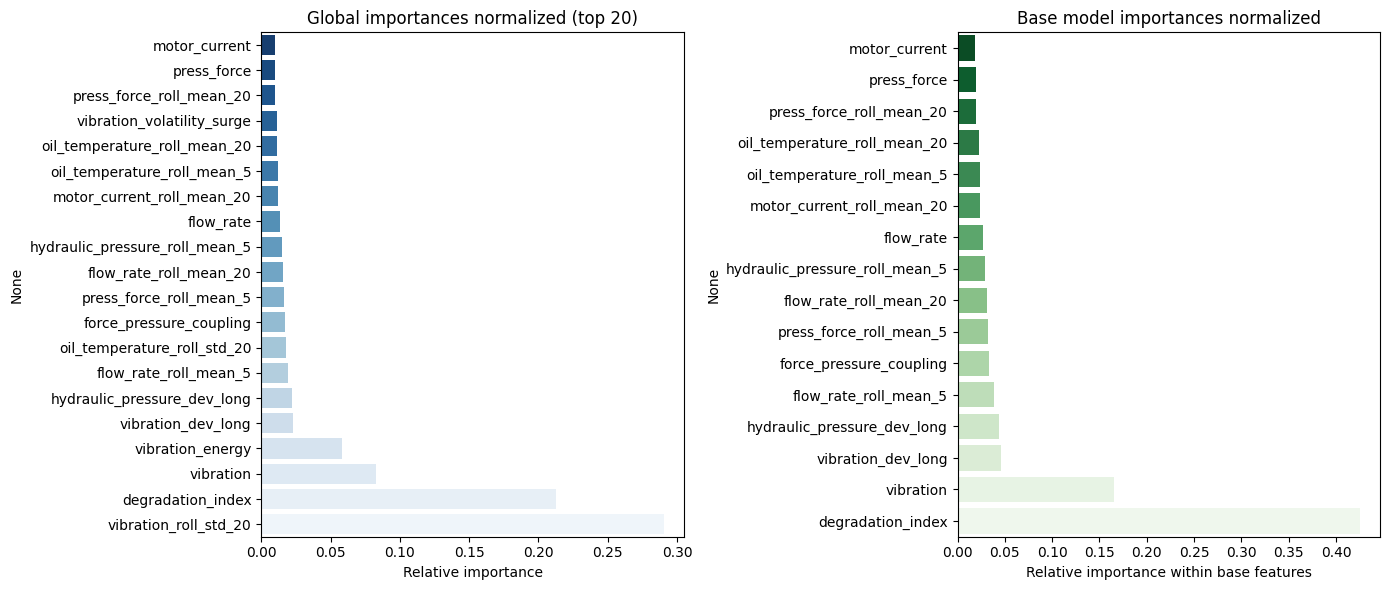

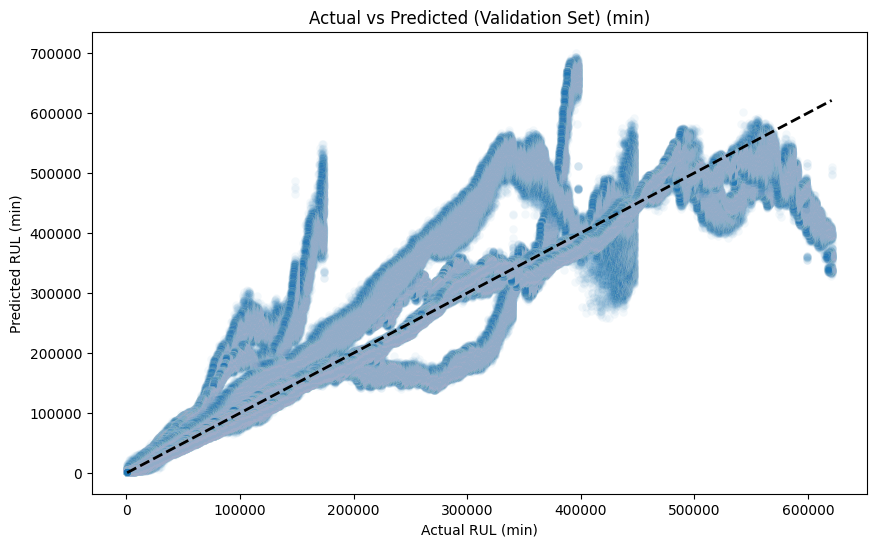

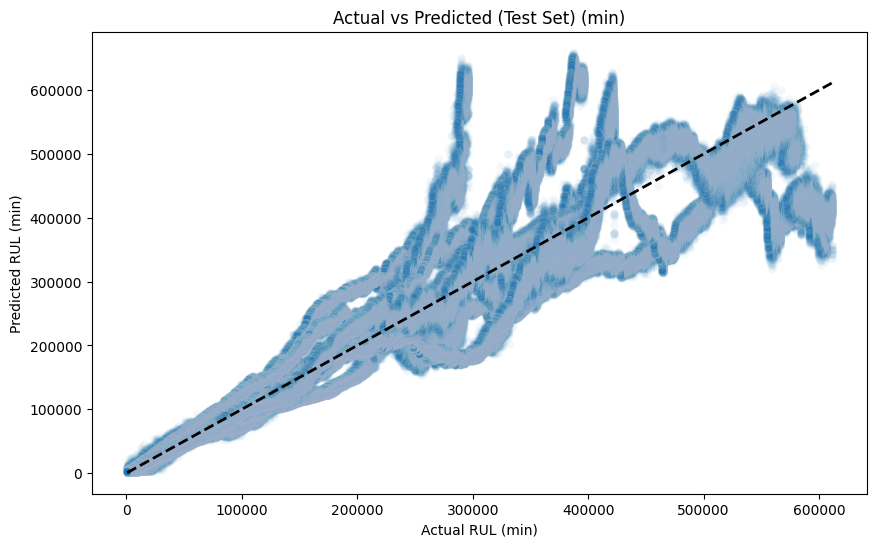

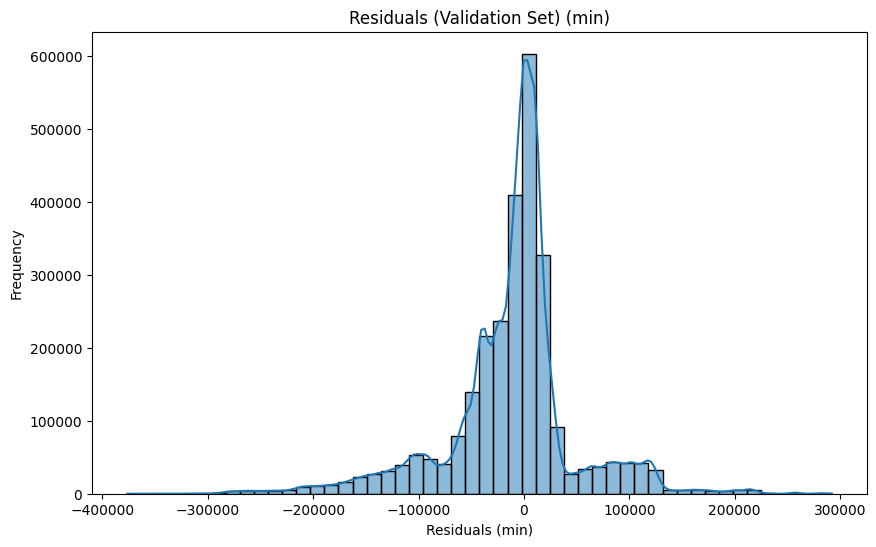

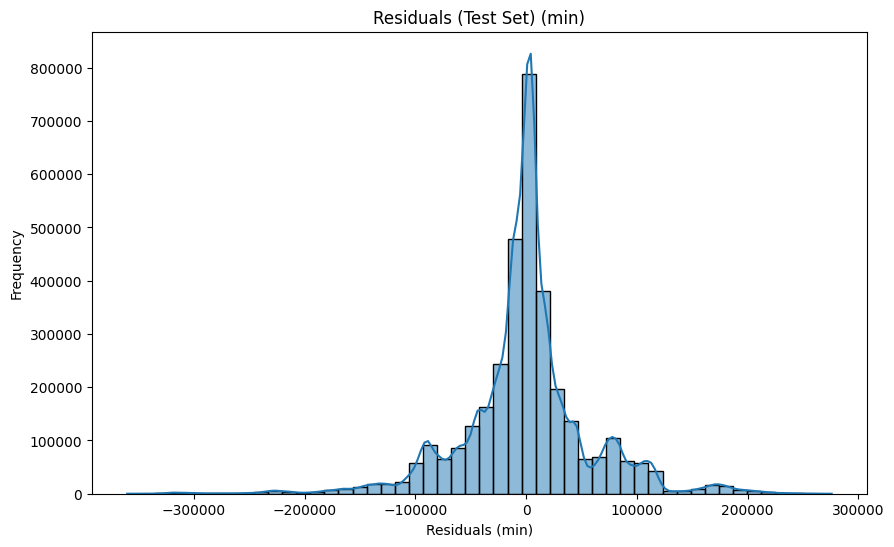

In [17]:
# 7B / Model Visualization - Feature Importance & predictions
print_header("7B/ VISUALIZATION - Feature Importance & Predictions vs True RUL")

# keep existing helper plotting functions intact
def plot_actual_vs_predicted(y_true, y_pred, title, unit_label="minutes"):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.05)
    mn, mx = np.nanmin(y_true), np.nanmax(y_true)
    plt.plot([mn, mx], [mn, mx], 'k--', lw=2)
    plt.title(f"{title} ({unit_label})")
    plt.xlabel(f'Actual RUL ({unit_label})')
    plt.ylabel(f'Predicted RUL ({unit_label})')
    plt.show()

def plot_residuals(y_true, y_pred, title, unit_label="minutes"):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=50, kde=True)
    plt.title(f"{title} ({unit_label})")
    plt.xlabel(f'Residuals ({unit_label})')
    plt.ylabel('Frequency')
    plt.show()

# prepare importance series for comparison
global_importances = importances.copy()  # XGBoost computed importances across full candidate set
global_normalized = global_importances / global_importances.sum()

base_model_importances = global_importances.reindex(base_model_features).fillna(0)
base_sum = base_model_importances.sum()
if base_sum > 0:
    base_normalized = base_model_importances / base_sum
else:
    base_normalized = base_model_importances

# quick text diagnostics
print("Top global importances (first 15):")
print(global_importances.head(15))
absent_top_global = [f for f in global_importances.head(10).index if f not in base_model_features]
print("\nGlobal top features missing in base model features:")
print(absent_top_global)
print("\nTop base model features after reindexing and normalization (first 15):")
print(base_normalized.sort_values(ascending=False).head(15))

# plotting side by side for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(base_model_features) * 0.2)))

# left plot global top20 normalized
topn = 20
global_plot = global_normalized.head(topn)
sns.barplot(x=global_plot.values[::-1], y=global_plot.index[::-1], ax=axes[0], palette="Blues_r")
axes[0].set_title("Global importances normalized (top 20)")
axes[0].set_xlabel("Relative importance")

# right plot base model normalized (all base features sorted)
base_plot = base_normalized.sort_values(ascending=False)
sns.barplot(x=base_plot.values[::-1], y=base_plot.index[::-1], ax=axes[1], palette="Greens_r")
axes[1].set_title("Base model importances normalized")
axes[1].set_xlabel("Relative importance within base features")

plt.tight_layout()
plt.show()

# show predictions and residuals as before
plot_actual_vs_predicted(y_val_true_min, val_pred_min, 'Actual vs Predicted (Validation Set)', unit_label="min")
plot_actual_vs_predicted(y_test_true_min, test_pred_min, 'Actual vs Predicted (Test Set)', unit_label="min")

plot_residuals(y_val_true_min, val_pred_min, 'Residuals (Validation Set)', unit_label="min")
plot_residuals(y_test_true_min, test_pred_min, 'Residuals (Test Set)', unit_label="min")

## 8) Two Stage Models

### 8.1) STAGE 1 - Critical Region Classification

In [ ]:
# 8/ Stage-1 Critical Region Classification
print_header("8/ STAGE-1 CRITICAL REGION CLASSIFICATION")

# Stage-1 threshold: boundary between NON_CRITICAL and CRITICAL
# Based on architecture: CRITICAL regime starts at RUL <= 600 minutes
STAGE1_THRESHOLD_MIN = 600

print("Purpose: Detect transition to CRITICAL regime (action required)")
print(f"Stage-1 threshold: RUL <= {STAGE1_THRESHOLD_MIN} minutes -> CRITICAL (1)")

# Preconditions
assert 'df_train_short' in globals(), "df_train_short not found"
assert 'df_val_short' in globals(), "df_val_short not found"
assert 'df_test_short' in globals(), "df_test_short not found"

print("\nDefining Stage-1 targets on Short-Life dataset...")

def define_stage1_target(y_values, threshold=STAGE1_THRESHOLD_MIN):
    return (y_values <= threshold).astype(int)

y_train_stage1 = define_stage1_target(y_train_short)
y_val_stage1   = define_stage1_target(y_val_short)
y_test_stage1  = define_stage1_target(y_test_short)

X_train_stage1 = X_train_short.copy()
X_val_stage1   = X_val_short.copy()
X_test_stage1  = X_test_short.copy()

print("Stage-1 dataset shapes:")
print(f"  Train X: {X_train_stage1.shape} | y: {y_train_stage1.shape}")
print(f"  Val   X: {X_val_stage1.shape}   | y: {y_val_stage1.shape}")
print(f"  Test  X: {X_test_stage1.shape}  | y: {y_test_stage1.shape}")

print("\nStage-1 class distribution (train):")
class_counts = y_train_stage1.value_counts()
print(f"  NON_CRITICAL (0): {class_counts.get(0, 0):,} samples ({class_counts.get(0, 0)/len(y_train_stage1)*100:.2f}%)")
print(f"  CRITICAL (1)    : {class_counts.get(1, 0):,} samples ({class_counts.get(1, 0)/len(y_train_stage1)*100:.2f}%)")

print("\nTraining Stage-1 classifier...")

stage1_model = XGBClassifier(
                                n_estimators=300,
                                max_depth=6,
                                learning_rate=0.05,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                objective="binary:logistic",
                                eval_metric="logloss",
                                random_state=42,
                                n_jobs=4,
                                verbosity=0
                            )

stage1_model.fit(
                    X_train_stage1,
                    y_train_stage1,
                    eval_set=[(X_val_stage1, y_val_stage1)],
                    verbose=False
                )

print("Evaluating Stage-1 classifier...")

y_val_pred_stage1 = stage1_model.predict(X_val_stage1)
y_val_prob_stage1 = stage1_model.predict_proba(X_val_stage1)[:, 1]

print("\nValidation classification report:")
print(classification_report(y_val_stage1, y_val_pred_stage1, digits=4,
                           target_names=["NON_CRITICAL", "CRITICAL"]))

val_auc_stage1 = roc_auc_score(y_val_stage1, y_val_prob_stage1)
print(f"Validation ROC AUC: {val_auc_stage1:.4f}")

# Save Model
joblib_path = os.path.join(save_path, "hydraulic_press_stage1_classifier.pkl")
joblib.dump(stage1_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

print_footer("STAGE-1 CLASSIFICATION COMPLETE")


8/ STAGE-1 CRITICAL REGION CLASSIFICATION
Purpose: Detect transition to CRITICAL regime (action required)
Stage-1 threshold: RUL <= 600 minutes -> CRITICAL (1)

Defining Stage-1 targets on Short-Life dataset...
Stage-1 dataset shapes:
  Train X: (183656, 20) | y: (183656,)
  Val   X: (37951, 20)   | y: (37951,)
  Test  X: (40085, 20)  | y: (40085,)

Stage-1 class distribution (train):
  NON_CRITICAL (0): 120,552 samples (65.64%)
  CRITICAL (1)    : 63,104 samples (34.36%)

Training Stage-1 classifier...
Evaluating Stage-1 classifier...

Validation classification report:
              precision    recall  f1-score   support

NON_CRITICAL     0.9574    0.9474    0.9524     24729
    CRITICAL     0.9035    0.9212    0.9123     13222

    accuracy                         0.9383     37951
   macro avg     0.9305    0.9343    0.9323     37951
weighted avg     0.9386    0.9383    0.9384     37951

Validation ROC AUC: 0.9792
Model saved (joblib): models_and_features/hydraulic_press/hydraulic_

### 8.2) STAGE 2A - Critical Regression

In [ ]:
# 8A/ Stage-2A Critical RUL Regression
print_header("8A/ STAGE-2A CRITICAL RUL REGRESSION")

# Preconditions
assert 'df_train_short' in globals(), "df_train_short not found"
assert 'df_val_short' in globals(), "df_val_short not found"
assert 'df_test_short' in globals(), "df_test_short not found"
assert 'selected_features' in globals(), "selected_features not found"

# Stage-2A operating range: only critical samples (RUL <= 600 min)
STAGE2A_MAX_RUL_MIN = 600

print("Purpose: High-resolution RUL prediction in CRITICAL regime")
print(f"Stage-2A operating range: RUL <= {STAGE2A_MAX_RUL_MIN} minutes")

print("\nFiltering critical samples for Stage-2A...")

def filter_stage2a_samples(df, y_values, max_rul=STAGE2A_MAX_RUL_MIN):
    mask = y_values <= max_rul
    return df[mask].copy(), y_values[mask].copy()

X_train_stage2a, y_train_stage2a_raw = filter_stage2a_samples(X_train_short, y_train_short)
X_val_stage2a, y_val_stage2a_raw = filter_stage2a_samples(X_val_short, y_val_short)
X_test_stage2a, y_test_stage2a_raw = filter_stage2a_samples(X_test_short, y_test_short)

# Also keep df subsets for cycle_id access later
df_train_stage2a = df_train_short[y_train_short <= STAGE2A_MAX_RUL_MIN].copy()
df_val_stage2a = df_val_short[y_val_short <= STAGE2A_MAX_RUL_MIN].copy()
df_test_stage2a = df_test_short[y_test_short <= STAGE2A_MAX_RUL_MIN].copy()

assert len(X_train_stage2a) > 0, "No training samples in critical range"
assert len(X_val_stage2a) > 0, "No validation samples in critical range"
assert len(X_test_stage2a) > 0, "No test samples in critical range"

print("Stage-2A dataset shapes:")
print(f"  Train: {X_train_stage2a.shape}")
print(f"  Val  : {X_val_stage2a.shape}")
print(f"  Test : {X_test_stage2a.shape}")

print("\nSelecting Stage-2A specific feature subset...")
print("  Priority: degradation indicators, energy, acceleration, volatility features")

stage2a_features = []

priority_keywords = [
                        "degradation_index",
                        "vibration",
                        "motor_current",
                        "oil_temperature",
                        "pressure",
                        "force_pressure",
                        "energy",
                        "acceleration",
                        "volatility",
                        "slope"
                    ]

for key in priority_keywords:
    matched = [f for f in selected_features if key in f]
    stage2a_features.extend(matched)

stage2a_features = list(dict.fromkeys(stage2a_features))

if len(stage2a_features) < 6:
    fallback_features = [
                            f for f in selected_features
                            if f not in stage2a_features
                        ]
    stage2a_features.extend(fallback_features[:(6 - len(stage2a_features))])

assert len(stage2a_features) >= 6, "Insufficient Stage-2A features"

print(f"Stage-2A feature count: {len(stage2a_features)}")
print(f"Features: {stage2a_features[:5]}...")

X_train_stage2a = X_train_stage2a[stage2a_features]
X_val_stage2a   = X_val_stage2a[stage2a_features]
X_test_stage2a  = X_test_stage2a[stage2a_features]

# Target transformation: log1p for stable learning
print("\nTransforming targets to log-space...")
y_train_stage2a = np.log1p(y_train_stage2a_raw.values)
y_val_stage2a   = np.log1p(y_val_stage2a_raw.values)
y_test_stage2a  = np.log1p(y_test_stage2a_raw.values)

print("Computing decision-aligned sample weights...")
print("  Higher weight for samples closer to failure (RUL -> 0)")

def compute_decision_aligned_weights(rul_values):
    normalized_distance = np.clip(rul_values / STAGE2A_MAX_RUL_MIN, 0.0, 1.0)
    decision_weights = 1.0 + (1.0 - normalized_distance) ** 3 * 7.0
    return decision_weights

train_sample_weights = compute_decision_aligned_weights(y_train_stage2a_raw.values)
val_sample_weights   = compute_decision_aligned_weights(y_val_stage2a_raw.values)

assert len(train_sample_weights) == len(y_train_stage2a)
assert len(val_sample_weights) == len(y_val_stage2a)

print("\nTraining weighted Stage-2A regressor...")

# Monotonic constraint: degradation_index should be monotonically related to RUL
monotone_constraints = [0] * len(stage2a_features)
if 'degradation_index' in stage2a_features:
    idx = stage2a_features.index('degradation_index')
    monotone_constraints[idx] = -1

stage2a_model = XGBRegressor(
                                n_estimators=1200,
                                max_depth=4,
                                learning_rate=0.03,
                                subsample=0.9,
                                colsample_bytree=0.9,
                                min_child_weight=5,
                                objective="reg:squarederror",
                                random_state=42,
                                n_jobs=4,
                                verbosity=0,
                                monotone_constraints=tuple(monotone_constraints)
                            )

stage2a_model.fit(
                    X_train_stage2a,
                    y_train_stage2a,
                    sample_weight=train_sample_weights,
                    eval_set=[(X_val_stage2a, y_val_stage2a)],
                    sample_weight_eval_set=[val_sample_weights],
                    early_stopping_rounds=70,
                    verbose=False
                )

print("Evaluating Stage-2A regressor...")

# Predictions in log-domain, inverse-transform to minutes
val_pred_log = stage2a_model.predict(X_val_stage2a)
val_predictions = np.expm1(val_pred_log)

test_pred_log = stage2a_model.predict(X_test_stage2a)
test_predictions = np.expm1(test_pred_log)

# Decision-aware clipping per cycle
val_window_max = df_val_stage2a.groupby('cycle_id')["current_rul"].transform('max').values
test_window_max = df_test_stage2a.groupby('cycle_id')["current_rul"].transform('max').values

val_predictions = np.clip(val_predictions, 0.0, val_window_max)
test_predictions = np.clip(test_predictions, 0.0, test_window_max)

# Evaluate against raw minute-scale targets
val_mae = MAE(y_val_stage2a_raw, val_predictions)
val_rmse = MSE(y_val_stage2a_raw, val_predictions, squared=False)
val_r2 = r2_score(y_val_stage2a_raw, val_predictions)

test_mae = MAE(y_test_stage2a_raw, test_predictions)
test_rmse = MSE(y_test_stage2a_raw, test_predictions, squared=False)
test_r2 = r2_score(y_test_stage2a_raw, test_predictions)

print("\nValidation Metrics:")
print(f"  MAE  : {val_mae:.2f} min")
print(f"  RMSE : {val_rmse:.2f} min")
print(f"  R2   : {val_r2 * 100:.2f}%")

print("\nTest Metrics:")
print(f"  MAE  : {test_mae:.2f} min")
print(f"  RMSE : {test_rmse:.2f} min")
print(f"  R2   : {test_r2 * 100:.2f}%")

# Critical decision error analysis (target: MAE < 40 min for RUL <= 300)
critical_error_threshold = 30.0
very_critical_mask = y_test_stage2a_raw <= 300

if very_critical_mask.sum() > 0:
    very_critical_mae = MAE(
                                y_test_stage2a_raw[very_critical_mask],
                                test_predictions[very_critical_mask]
                            )
    print(f"\nVery Critical Region (RUL <= 300 min):")
    print(f"  Samples: {very_critical_mask.sum()}")
    print(f"  MAE    : {very_critical_mae:.2f} min")


# save model
joblib_path = os.path.join(save_path, "hydraulic_press_stage2a_regressor.pkl")
joblib.dump(stage2a_model, joblib_path, compress=('lz4', 3))  
print(f"Model saved (joblib): {joblib_path}")

print_footer("STAGE-2A CRITICAL RUL REGRESSION COMPLETE")


8A/ STAGE-2A CRITICAL RUL REGRESSION
Purpose: High-resolution RUL prediction in CRITICAL regime
Stage-2A operating range: RUL <= 600 minutes

Filtering critical samples for Stage-2A...
Stage-2A dataset shapes:
  Train: (63104, 20)
  Val  : (13222, 20)
  Test : (13823, 20)

Selecting Stage-2A specific feature subset...
  Priority: degradation indicators, energy, acceleration, volatility features
Stage-2A feature count: 14
Features: ['degradation_index', 'vibration_roll_std_20', 'vibration', 'vibration_energy', 'vibration_dev_long']...

Transforming targets to log-space...
Computing decision-aligned sample weights...
  Higher weight for samples closer to failure (RUL -> 0)

Training weighted Stage-2A regressor...
Evaluating Stage-2A regressor...

Validation Metrics:
  MAE  : 48.69 min
  RMSE : 60.82 min
  R2   : 87.71%

Test Metrics:
  MAE  : 45.92 min
  RMSE : 57.53 min
  R2   : 89.00%

Very Critical Region (RUL <= 300 min):
  Samples: 6923
  MAE    : 32.58 min
Model saved (joblib): mo

## 9) Two Stage Inference & Evaluation

In [20]:
# 9/ TWO-STAGE INFERENCE AND EVALUATION
print_header("9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE")

# Architecture Overview:
# Stage-0: LONG_TERM vs NEAR_TERM regime detection (trained on Long-Life)
# Stage-1: NON_CRITICAL vs CRITICAL detection (trained on Short-Life)
# Base Model: Long-term RUL tracking (LONG_TERM + transition regime)
# Stage-2A: High-resolution critical RUL (CRITICAL regime only)

# Preconditions
assert 'stage0_model' in globals(), "Stage-0 classifier not found"
assert 'stage1_model' in globals(), "Stage-1 classifier not found"
assert 'base_model' in globals(), "Base Model regressor not found"
assert 'stage2a_model' in globals(), "Stage-2A regressor not found"
assert 'base_model_features' in globals(), "base_model_features not found"
assert 'stage2a_features' in globals(), "stage2a_features not found"


# PART A: BASE MODEL + STAGE-0 EVALUATION (LONG-LIFE TEST SET)
print("\n" + "=" * 60)
print("PART A: BASE MODEL + STAGE-0 (Long-Life Test Set)")
print("=" * 60)

X_eval_long = X_test_long.copy()
y_eval_long = y_test_long.copy()

print(f"Long-Life Evaluation set: {len(y_eval_long):,} samples")
print(f"RUL range: {y_eval_long.min():.0f} - {y_eval_long.max():.0f} minutes")

# STAGE-0: Regime Detection
print("\n[Stage-0] Regime detection (LONG_TERM vs NEAR_TERM)...")
stage0_prob_long = stage0_model.predict_proba(X_eval_long)[:, 1]
stage0_pred_long = (stage0_prob_long >= 0.5).astype(int)
n_long_term = (stage0_pred_long == 0).sum()
n_near_term = (stage0_pred_long == 1).sum()
print(f"  LONG_TERM: {n_long_term:,} | NEAR_TERM: {n_near_term:,}")

# BASE MODEL: Default prediction for all samples (Long-Life context)
print("\n[Base Model] Long-term RUL tracking...")

missing_base = [c for c in base_model_features if c not in X_eval_long.columns]
if len(missing_base) > 0:
    raise ValueError(f"Missing base model features: {missing_base}")

base_pred_log_long = base_model.predict(X_eval_long[base_model_features])
base_pred_hr_long = np.expm1(base_pred_log_long)
base_pred_min_long = base_pred_hr_long * 60.0

# Base Model Metrics
base_mae_long = MAE(y_eval_long, base_pred_min_long)
base_r2_long = r2_score(y_eval_long, base_pred_min_long)
print(f"  Base Model MAE: {base_mae_long:.2f} min")
print(f"  Base Model R2 : {base_r2_long*100:.2f}%")

# Stratified Analysis (Base Model on Long-Life)
print("\nBase Model Stratified Performance (Long-Life):")
print(f"{'RUL Range':<20} {'N':>8} {'MAE':>10} {'Rel.Err':>10}")
print("-" * 50)

bins_long = [
                (5000, 20000, "Mid Term"),
                (20000, 100000, "Long Term"),
                (100000, float('inf'), "Very Long Term")
            ]

for low, high, label in bins_long:
    mask = (y_eval_long >= low) & (y_eval_long < high)
    if mask.sum() == 0:
        continue
    bin_mae = MAE(y_eval_long[mask], base_pred_min_long[mask])
    avg_rul = y_eval_long[mask].mean()
    rel_err = (bin_mae / avg_rul) * 100 if avg_rul > 0 else 0
    print(f"{label:<20} {mask.sum():>8,} {bin_mae:>10.2f} {rel_err:>9.1f}%")



# PART B: STAGE-1 + STAGE-2A EVALUATION (SHORT-LIFE TEST SET)
print("\n" + "=" * 60)
print("PART B: STAGE-1 + STAGE-2A (Short-Life Test Set)")
print("=" * 60)

X_eval_short = X_test_short.copy()
y_eval_short = y_test_short.copy()

print(f"Short-Life Evaluation set: {len(y_eval_short):,} samples")
print(f"RUL range: {y_eval_short.min():.0f} - {y_eval_short.max():.0f} minutes")

# STAGE-1: Critical Detection (only valid for Short-Life context)
print("\n[Stage-1] Critical detection (NON_CRITICAL vs CRITICAL)...")

THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2

critical_prob_short = stage1_model.predict_proba(X_eval_short)[:, 1]

critical_flag_short = np.zeros_like(critical_prob_short, dtype=int)
critical_flag_short[critical_prob_short >= THRESH_ENTER] = 1
critical_flag_short[critical_prob_short <= THRESH_EXIT]  = 0
critical_flag_short[(critical_prob_short > THRESH_EXIT) & (critical_prob_short < THRESH_ENTER)] = -1

n_critical = (critical_flag_short == 1).sum()
n_non_critical = (critical_flag_short == 0).sum()
n_uncertain = (critical_flag_short == -1).sum()
print(f"  CRITICAL: {n_critical:,} | NON_CRITICAL: {n_non_critical:,} | UNCERTAIN: {n_uncertain:,}")


final_pred_short = np.full(len(X_eval_short), np.nan, dtype=float)

# BASE MODEL: Fallback for NON_CRITICAL and UNCERTAIN samples
print("\n[Base Model] Fallback for NON_CRITICAL and UNCERTAIN samples...")

idx_non_critical_short = np.where(critical_flag_short != 1)[0]

if len(idx_non_critical_short) > 0:
    missing_base_short = [c for c in base_model_features if c not in X_eval_short.columns]
    if len(missing_base_short) > 0:
        raise ValueError(f"Missing base model features: {missing_base_short}")
    
    X_non_crit_short = X_eval_short.iloc[idx_non_critical_short][base_model_features]
    
    base_pred_log_short = base_model.predict(X_non_crit_short)
    base_pred_hr_short = np.expm1(base_pred_log_short)
    base_pred_min_short = base_pred_hr_short * 60.0
    
    final_pred_short[idx_non_critical_short] = base_pred_min_short
    print(f"  Applied Base Model to {len(idx_non_critical_short):,} non-critical samples")
else:
    print("  All samples are critical, no fallback needed")

# STAGE-2A: Override for CRITICAL samples
print("\n[Stage-2A] Critical RUL refinement (Short-Life)...")

idx_critical_short = np.where(critical_flag_short == 1)[0]

if len(idx_critical_short) > 0:
    missing_s2a = [c for c in stage2a_features if c not in X_eval_short.columns]
    if len(missing_s2a) > 0:
        raise ValueError(f"Missing Stage-2A features: {missing_s2a}")
    
    X_crit_short = X_eval_short.iloc[idx_critical_short][stage2a_features]
    
    pred_2a_log_short = stage2a_model.predict(X_crit_short)
    pred_2a_short = np.expm1(pred_2a_log_short)
    pred_2a_short = np.clip(pred_2a_short, 0.0, STAGE2A_MAX_RUL_MIN)
    
    final_pred_short[idx_critical_short] = pred_2a_short
    print(f"  Applied Stage-2A to {len(idx_critical_short):,} critical samples")
else:
    print("  No critical samples detected by Stage-1")

# Verify no NaN values remain
nan_count = np.isnan(final_pred_short).sum()
if nan_count > 0:
    print(f"  WARNING: {nan_count} samples still have NaN predictions")
else:
    print(f"  All {len(final_pred_short):,} samples have valid predictions")

final_pred_short = np.clip(final_pred_short, 0, 720000)

# FINAL EVALUATION: CRITICAL REGION ON SHORT-LIFE
print("\n" + "=" * 60)
print("FINAL SYSTEM PERFORMANCE (SHORT-LIFE TEST SET)")
print("=" * 60)

final_mae_short = MAE(y_eval_short, final_pred_short)
final_rmse_short = R_MSE(y_eval_short, final_pred_short)
final_r2_short = r2_score(y_eval_short, final_pred_short)

print(f"\nOverall Metrics (Short-Life):")
print(f"  MAE : {final_mae_short:.2f} min")
print(f"  RMSE: {final_rmse_short:.2f} min")
print(f"  R2  : {final_r2_short*100:.2f}%")

# Stratified Analysis
print("\nStratified Performance (Short-Life):")
print(f"{'RUL Range':<20} {'N':>8} {'MAE':>10} {'Rel.Err':>10}")
print("-" * 50)

bins_short = [
                (0, 100, "Very Critical"),
                (100, 300, "Critical"),
                (300, 600, "Near Critical"),
                (600, 1500, "Transition"),
                (1500, float('inf'), "Beyond Critical")
            ]

for low, high, label in bins_short:
    mask = (y_eval_short >= low) & (y_eval_short < high)
    if mask.sum() == 0:
        continue
    
    bin_mae = MAE(y_eval_short[mask], final_pred_short[mask])
    avg_rul = y_eval_short[mask].mean()
    rel_err = (bin_mae / avg_rul) * 100 if avg_rul > 0 else 0
    
    print(f"{label:<20} {mask.sum():>8,} {bin_mae:>10.2f} {rel_err:>9.1f}%")

# Critical Region Metrics (Project Target on Short-Life)
print("\n" + "=" * 60)
print("CRITICAL REGION ANALYSIS (RUL <= 600 min) - SHORT-LIFE")
print("=" * 60)

crit_mask_short = y_eval_short <= 600
n_crit_short = crit_mask_short.sum()

if n_crit_short > 0:
    crit_mae_short = MAE(y_eval_short[crit_mask_short], final_pred_short[crit_mask_short])
    crit_acc_10min_short = (np.abs(y_eval_short[crit_mask_short] - final_pred_short[crit_mask_short]) <= ACCURACY_TOLERANCE).mean() * 100
    crit_acc_40min_short = (np.abs(y_eval_short[crit_mask_short] - final_pred_short[crit_mask_short]) <= 40).mean() * 100
    
    print(f"  Samples        : {n_crit_short:,}")
    print(f"  MAE            : {crit_mae_short:.2f} min (target: < 40 min)")
    print(f"  +/- 10 min acc : {crit_acc_10min_short:.1f}%")
    print(f"  +/- 40 min acc : {crit_acc_40min_short:.1f}% (target: > 60%)")
    
    very_crit_mask_short = y_eval_short <= 300
    if very_crit_mask_short.sum() > 0:
        very_crit_mae_short = MAE(y_eval_short[very_crit_mask_short], final_pred_short[very_crit_mask_short])
        print(f"\n  Very Critical (RUL <= 300):")
        print(f"    Samples: {very_crit_mask_short.sum():,}")
        print(f"    MAE    : {very_crit_mae_short:.2f} min")
else:
    print("  No critical samples in Short-Life test set")

# Store for sanity check cell
final_pred = final_pred_short
X_eval = X_eval_short
y_eval = y_eval_short

print_footer("FINAL TWO-STAGE PIPELINE COMPLETE")


9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE

PART A: BASE MODEL + STAGE-0 (Long-Life Test Set)
Long-Life Evaluation set: 3,398,614 samples
RUL range: 0 - 610898 minutes

[Stage-0] Regime detection (LONG_TERM vs NEAR_TERM)...
  LONG_TERM: 3,353,176 | NEAR_TERM: 45,438

[Base Model] Long-term RUL tracking...
  Base Model MAE: 37423.97 min
  Base Model R2 : 85.12%

Base Model Stratified Performance (Long-Life):
RUL Range                   N        MAE    Rel.Err
--------------------------------------------------
Mid Term              120,000    2837.69      22.7%
Long Term             640,000    8690.14      14.5%
Very Long Term       2,598,614   46647.88      16.5%

PART B: STAGE-1 + STAGE-2A (Short-Life Test Set)
Short-Life Evaluation set: 40,085 samples
RUL range: 0 - 2861 minutes

[Stage-1] Critical detection (NON_CRITICAL vs CRITICAL)...
  CRITICAL: 13,553 | NON_CRITICAL: 25,103 | UNCERTAIN: 1,429

[Base Model] Fallback for NON_CRITICAL and UNCERTAIN samples...
  Applied Base

## 10) Sanity Checks

In [ ]:
# 10/ SANITY CHECKS - Multi-Resolution RUL System
print_header("10/ SANITY CHECKS - Hydraulic Press Multi-Resolution RUL Pipeline")

# Preconditions
assert 'stage0_model' in globals(), "Stage-0 classifier missing"
assert 'stage1_model' in globals(), "Stage-1 classifier missing"
assert 'base_model' in globals(), "Base Model regressor missing"
assert 'stage2a_model' in globals(), "Stage-2A regressor missing"

# Hysteresis thresholds
THRESH_ENTER = 0.6
THRESH_EXIT  = 0.2


# STAGE-0 SANITY CHECK (Long-Life Test Set)
print("\n=== STAGE-0: REGIME DETECTOR (LONG_TERM vs NEAR_TERM) ===")
print("Test data: Long-Life (Stage-0 trained on Long-Life)")

y_test_regime_true = (y_test_long <= STAGE0_THRESHOLD_MIN).astype(int)
y_test_regime_prob = stage0_model.predict_proba(X_test_long)[:, 1]
y_test_regime_pred = (y_test_regime_prob >= 0.5).astype(int)

regime_tp = ((y_test_regime_pred == 1) & (y_test_regime_true == 1)).sum()
regime_fn = ((y_test_regime_pred == 0) & (y_test_regime_true == 1)).sum()
regime_fp = ((y_test_regime_pred == 1) & (y_test_regime_true == 0)).sum()

regime_recall = regime_tp / (regime_tp + regime_fn) if (regime_tp + regime_fn) > 0 else 0.0
regime_precision = regime_tp / (regime_tp + regime_fp) if (regime_tp + regime_fp) > 0 else 0.0

print(f"NEAR_TERM Recall   : {regime_recall:.3f}")
print(f"NEAR_TERM Precision: {regime_precision:.3f}")

stage0_pass = regime_recall >= 0.80
print(f"Stage-0 verdict    : {'PASS' if stage0_pass else 'FAIL'} (target recall >= 0.80)")



# STAGE-1 SANITY CHECK (Short-Life Test Set)
print("\n=== STAGE-1: CRITICAL DETECTOR (NON_CRITICAL vs CRITICAL) ===")
print("Test data: Short-Life (Stage-1 trained on Short-Life)")

# Stage-1
y_test_crit_true_short = (y_test_short <= STAGE1_THRESHOLD_MIN).astype(int)
y_test_crit_prob_short = stage1_model.predict_proba(X_test_short)[:, 1]

y_test_crit_pred_short = np.zeros_like(y_test_crit_prob_short, dtype=int)
y_test_crit_pred_short[y_test_crit_prob_short >= THRESH_ENTER] = 1
y_test_crit_pred_short[y_test_crit_prob_short <= THRESH_EXIT]  = 0

known_mask_short = (y_test_crit_prob_short >= THRESH_ENTER) | (y_test_crit_prob_short <= THRESH_EXIT)

tp_short = ((y_test_crit_pred_short == 1) & (y_test_crit_true_short == 1) & known_mask_short).sum()
fn_short = ((y_test_crit_pred_short == 0) & (y_test_crit_true_short == 1) & known_mask_short).sum()
fp_short = ((y_test_crit_pred_short == 1) & (y_test_crit_true_short == 0) & known_mask_short).sum()

crit_recall_short = tp_short / (tp_short + fn_short) if (tp_short + fn_short) > 0 else 0.0
crit_precision_short = tp_short / (tp_short + fp_short) if (tp_short + fp_short) > 0 else 0.0
fnr_short = fn_short / (tp_short + fn_short) if (tp_short + fn_short) > 0 else 0.0

print(f"Critical Recall      : {crit_recall_short:.3f}")
print(f"Critical Precision   : {crit_precision_short:.3f}")
print(f"False Negative Rate  : {fnr_short:.3f}")

stage1_pass = crit_recall_short >= 0.85
print(f"Stage-1 verdict      : {'PASS' if stage1_pass else 'FAIL'} (target recall >= 0.85)")



# STAGE-2A SANITY CHECK (Short-Life Test Set)
print("\n=== STAGE-2A: CRITICAL REGRESSOR ===")
print("Test data: Short-Life (Stage-2A trained on Short-Life)")

mask_very_critical_short = y_test_short <= 300
mask_critical_short = y_test_short <= STAGE2A_MAX_RUL_MIN

if mask_very_critical_short.sum() > 0:
    X_test_s2a_vc_short = X_test_short[mask_very_critical_short][stage2a_features]
    y_test_s2a_vc_short = y_test_short[mask_very_critical_short]
    pred_s2a_vc_log_short = stage2a_model.predict(X_test_s2a_vc_short)
    pred_s2a_vc_short = np.expm1(pred_s2a_vc_log_short)
    mae_s2a_vc_short = MAE(y_test_s2a_vc_short, pred_s2a_vc_short)
    print(f"Very Critical (<= 300 min): {mask_very_critical_short.sum():,} samples | MAE: {mae_s2a_vc_short:.2f} min")
    stage2a_pass_strict = mae_s2a_vc_short <= 40.0
else:
    print("No very critical samples in Short-Life test set")
    stage2a_pass_strict = True

if mask_critical_short.sum() > 0:
    X_test_s2a_c_short = X_test_short[mask_critical_short][stage2a_features]
    y_test_s2a_c_short = y_test_short[mask_critical_short]
    pred_s2a_c_log_short = stage2a_model.predict(X_test_s2a_c_short)
    pred_s2a_c_short = np.expm1(pred_s2a_c_log_short)
    mae_s2a_c_short = MAE(y_test_s2a_c_short, pred_s2a_c_short)
    print(f"Critical (<= 600 min)     : {mask_critical_short.sum():,} samples | MAE: {mae_s2a_c_short:.2f} min")
    stage2a_pass_relaxed = mae_s2a_c_short <= 60.0
else:
    print("No critical samples in Short-Life test set")
    stage2a_pass_relaxed = True

stage2a_pass = stage2a_pass_strict and stage2a_pass_relaxed
print(f"Stage-2A verdict     : {'PASS' if stage2a_pass else 'FAIL'}")



# FINAL SYSTEM SANITY CHECK (Short-Life)
print("\n=== FINAL SYSTEM (CRITICAL FOCUS - SHORT-LIFE) ===")

crit_proj = PROJECT_CRITICAL_THRESHOLD  # 100 min
mask_crit_final_short = y_test_short <= crit_proj



if mask_crit_final_short.sum() > 0:
    final_mae_crit_short = MAE(y_test_short[mask_crit_final_short], final_pred[mask_crit_final_short])
    final_acc_tol_short = (np.abs(y_test_short[mask_crit_final_short] - final_pred[mask_crit_final_short]) <= ACCURACY_TOLERANCE).mean() * 100
    final_acc_40_short = (np.abs(y_test_short[mask_crit_final_short] - final_pred[mask_crit_final_short]) <= 40).mean() * 100
    
    print(f"Samples (<= {crit_proj} min)  : {mask_crit_final_short.sum():,}")
    print(f"MAE                   : {final_mae_crit_short:.2f} min (target < 40)")
    print(f"+/- {ACCURACY_TOLERANCE} min accuracy : {final_acc_tol_short:.1f}%")
    print(f"+/- 40 min accuracy   : {final_acc_40_short:.1f}% (target > 60%)")
    
    final_system_pass = final_acc_40_short >= 60.0
else:
    print("No critical samples for final check in Short-Life test set")
    final_system_pass = False

print(f"Final system verdict : {'PASS' if final_system_pass else 'FAIL'}")



# DRIFT CHECK (Long-Life)
print("\n=== DRIFT CHECK (DIAGNOSTIC - Long-Life) ===")

ks_p_values = []
cols_to_check = [c for c in X_train_long.columns if pd.api.types.is_numeric_dtype(X_train_long[c])]
for col in cols_to_check:
    try:
        _, p = ks_2samp(X_train_long[col], X_test_long[col])
    except Exception:
        p = 1.0
    ks_p_values.append(p)

feature_drift_ratio = np.mean(np.array(ks_p_values) < 0.05)
_, target_p = ks_2samp(y_train_long, y_test_long)
print(f"Feature drift ratio: {feature_drift_ratio:.2f}")
print(f"Target KS p-value  : {target_p:.4f}")



# PERMUTATION IMPORTANCE (BASE MODEL)
print("\n=== PERMUTATION IMPORTANCE (BASE MODEL) ===")

def neg_mae_minutes(est, X, y_min):
    y_min = np.array(y_min, copy=True)
    preds_log = est.predict(X)
    preds_min = np.expm1(preds_log) * 60.0
    return -MAE(y_min, preds_min)

perm_res = permutation_importance(
                                    base_model,
                                    X_test_base,
                                    y_test_base_min.to_numpy().copy(),
                                    scoring=neg_mae_minutes,
                                    n_repeats=10,
                                    random_state=42,
                                    n_jobs=4
                                )
perm_importances = pd.Series(perm_res.importances_mean, index=X_test_base.columns).sort_values(ascending=False)
print("Top 10 features by permutation importance:")
for i, (feat, imp) in enumerate(perm_importances.head(10).items(), 1):
    print(f"  {i:2d}. {feat:35s} {imp:.4f}")



# ABLATION TEST (BASE MODEL)
print("\n=== ABLATION TEST (BASE MODEL) ===")

base_pred_log_full = base_model.predict(X_test_base)
base_pred_min_full = np.expm1(base_pred_log_full) * 60.0
base_mae_full = MAE(y_test_base_min, base_pred_min_full)
print(f"Baseline MAE: {base_mae_full:.2f} min")

top_features = perm_importances.head(min(5, len(perm_importances))).index.tolist()
print(f"\nAblation (median replacement):")
print(f"{'Feature':<35} {'MAE After':>12} {'Delta %':>10}")
print("-" * 60)

for f in top_features:
    X_ab = X_test_base.copy()
    X_ab[f] = X_ab[f].median()
    preds_log = base_model.predict(X_ab)
    preds_min = np.expm1(preds_log) * 60.0
    mae_ab = MAE(y_test_base_min, preds_min)
    delta_pct = (mae_ab - base_mae_full) / base_mae_full * 100.0
    print(f"{f:<35} {mae_ab:>12.2f} {delta_pct:>9.1f}%")



# DEGRADATION INDEX CORRELATION
print("\n=== DEGRADATION_INDEX vs RUL CORRELATION ===")

if 'degradation_index' in X_test_long.columns:
    
    
    pearson = np.corrcoef(X_test_long['degradation_index'], y_test_long)[0, 1]
    rho, pval = spearmanr(X_test_long['degradation_index'], y_test_long)
    print(f"Sample-level Pearson : {pearson:.3f}")
    print(f"Sample-level Spearman: {rho:.3f} (p={pval:.4f})")
else:
    print("degradation_index feature not found")



# FINAL SANITY SUMMARY
print("\n" + "=" * 60)
print("FINAL SANITY SUMMARY")
print("=" * 60)
print(f"Stage-0 Regime Detector  : {'PASS' if stage0_pass else 'FAIL'} (Long-Life test)")
print(f"Stage-1 Critical Detector: {'PASS' if stage1_pass else 'FAIL'} (Short-Life test)")
print(f"Stage-2A Critical Regressor: {'PASS' if stage2a_pass else 'FAIL'} (Short-Life test)")
print(f"Final Two-Stage System   : {'PASS' if final_system_pass else 'FAIL'} (Short-Life test)")

all_pass = stage0_pass and stage1_pass and stage2a_pass and final_system_pass
print(f"\nOVERALL SYSTEM STATUS    : {'PASS' if all_pass else 'NEEDS REVIEW'}")

print_footer("SANITY CHECKS COMPLETE")


10/ SANITY CHECKS - Hydraulic Press Multi-Resolution RUL Pipeline

=== STAGE-0: REGIME DETECTOR (LONG_TERM vs NEAR_TERM) ===
Test data: Long-Life (Stage-0 trained on Long-Life)


NEAR_TERM Recall   : 0.848
NEAR_TERM Precision: 0.746
Stage-0 verdict    : PASS (target recall >= 0.80)

=== STAGE-1: CRITICAL DETECTOR (NON_CRITICAL vs CRITICAL) ===
Test data: Short-Life (Stage-1 trained on Short-Life)
Critical Recall      : 0.959
Critical Precision   : 0.958
False Negative Rate  : 0.041
Stage-1 verdict      : PASS (target recall >= 0.85)

=== STAGE-2A: CRITICAL REGRESSOR ===
Test data: Short-Life (Stage-2A trained on Short-Life)
Very Critical (<= 300 min): 6,923 samples | MAE: 32.58 min
Critical (<= 600 min)     : 13,823 samples | MAE: 45.92 min
Stage-2A verdict     : PASS

=== FINAL SYSTEM (CRITICAL FOCUS - SHORT-LIFE) ===
Samples (<= 100 min)  : 2,323
MAE                   : 21.77 min (target < 40)
+/- 10 min accuracy : 30.8%
+/- 40 min accuracy   : 86.1% (target > 60%)
Final system verdict : PASS

=== DRIFT CHECK (DIAGNOSTIC - Long-Life) ===
Feature drift ratio: 1.00
Target KS p-value  : 0.0000

=== PERMUTATION IMPORTANCE (BASE MODEL) ===
Top 10 features by permu


10A/ MODEL BEHAVIOR VISUALIZATION


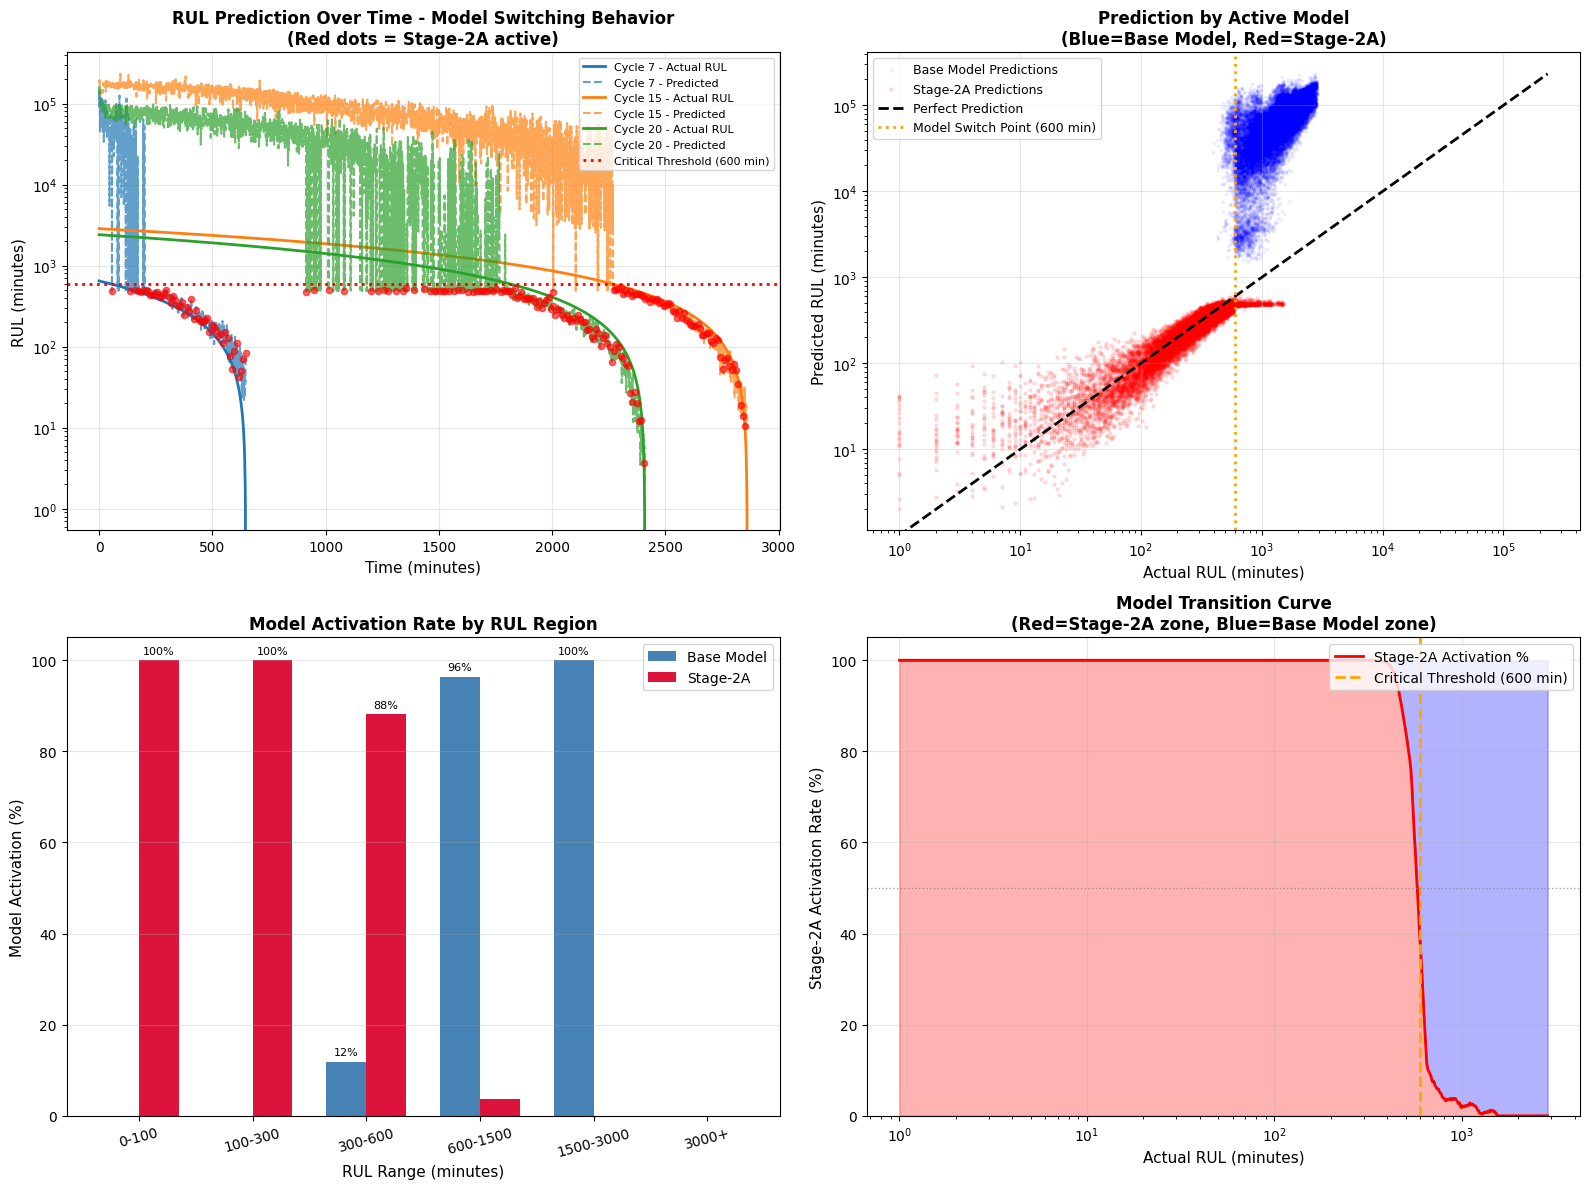

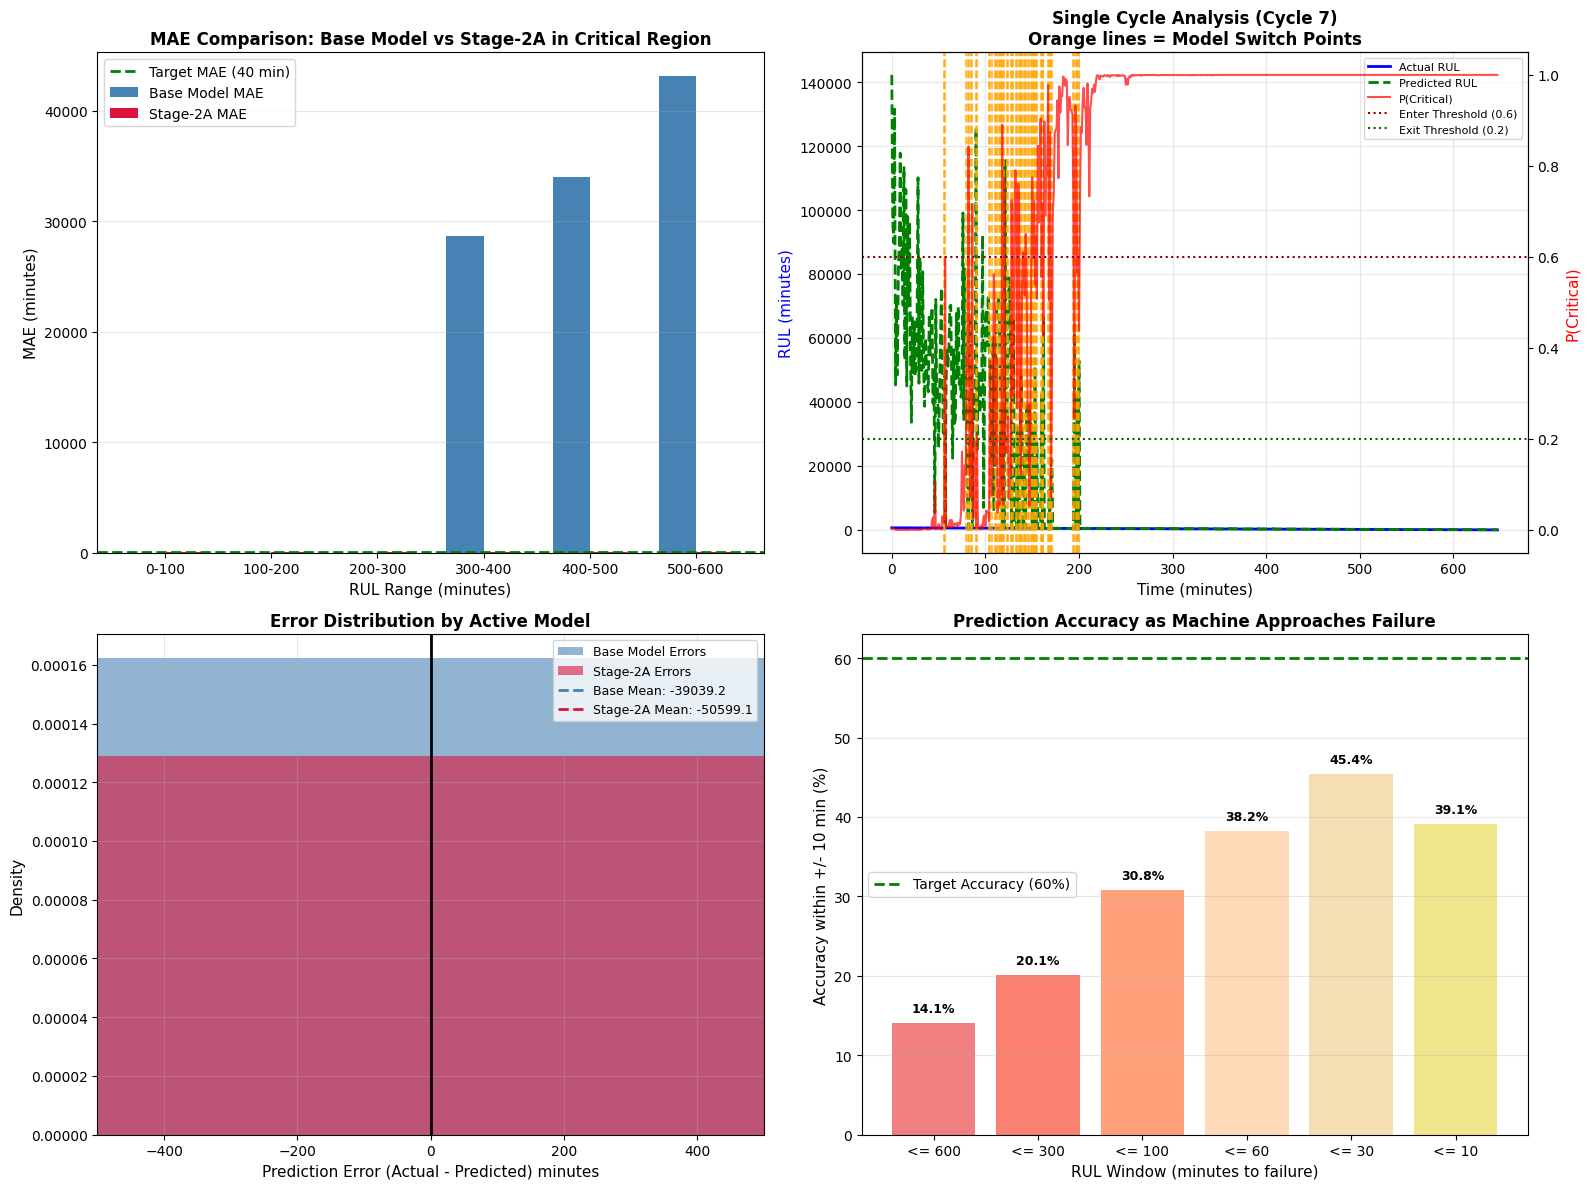

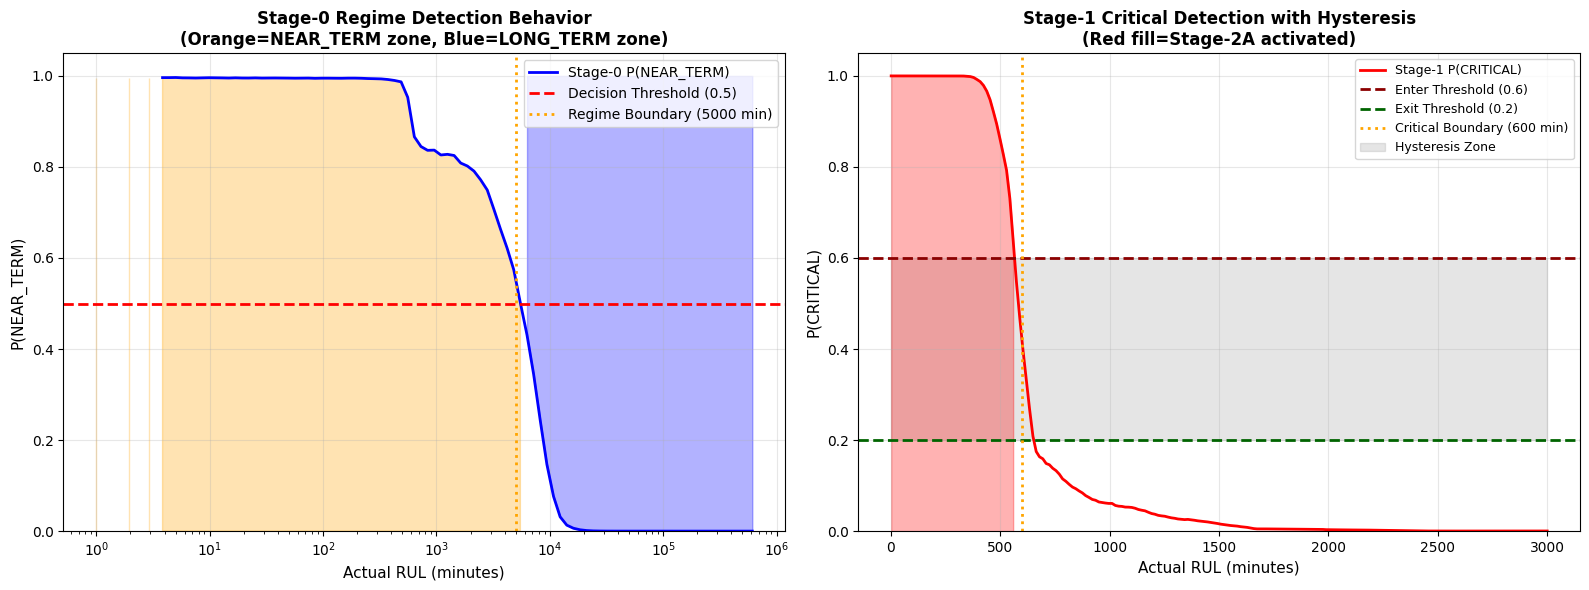


=== MODEL BEHAVIOR SUMMARY ===
Total test samples (Short-Life): 40,085
Base Model activated: 26,532 samples (66.2%)
Stage-2A activated: 13,553 samples (33.8%)

Base Model MAE (where active): 39061.41 min
Stage-2A MAE (where active): 50648.17 min

Combined MAE in critical region (RUL <= 300): 32.58 min

----------------------------------------------------------------------
MODEL BEHAVIOR VISUALIZATION COMPLETE
----------------------------------------------------------------------


In [ ]:
# 10A/ Multi-Resolution Pipeline Model Behavior Visualization
print_header("10A/ MODEL BEHAVIOR VISUALIZATION")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
sample_cycle_ids = df_test_short['cycle_id'].unique()[:3]
colors_cycle = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, cycle_id in enumerate(sample_cycle_ids):
    cycle_mask = df_test_short['cycle_id'] == cycle_id
    cycle_indices = np.where(cycle_mask)[0]
    
    cycle_rul = y_eval_short.iloc[cycle_indices].values
    cycle_pred = final_pred_short[cycle_indices]
    cycle_time = df_test_short.loc[cycle_mask, 'time_min'].values
    
    cycle_stage1_prob = critical_prob_short[cycle_indices]
    cycle_critical_flag = critical_flag_short[cycle_indices]
    
    ax1.plot(cycle_time, cycle_rul, '-', color=colors_cycle[idx], 
             linewidth=2, label=f'Cycle {cycle_id} - Actual RUL')
    ax1.plot(cycle_time, cycle_pred, '--', color=colors_cycle[idx], 
             linewidth=1.5, alpha=0.7, label=f'Cycle {cycle_id} - Predicted')
    
    critical_times = cycle_time[cycle_critical_flag == 1]
    critical_preds = cycle_pred[cycle_critical_flag == 1]
    if len(critical_times) > 0:
        ax1.scatter(critical_times[::10], critical_preds[::10], 
                   color='red', s=20, zorder=5, alpha=0.6)

ax1.axhline(y=STAGE1_THRESHOLD_MIN, color='red', linestyle=':', linewidth=2, 
            label=f'Critical Threshold ({STAGE1_THRESHOLD_MIN} min)')
ax1.set_xlabel('Time (minutes)', fontsize=11)
ax1.set_ylabel('RUL (minutes)', fontsize=11)
ax1.set_title('RUL Prediction Over Time - Model Switching Behavior\n(Red dots = Stage-2A active)', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(alpha=0.3)
ax1.set_yscale('log')

ax2 = axes[0, 1]
rul_sorted_idx = np.argsort(y_eval_short.values)
rul_sorted = y_eval_short.values[rul_sorted_idx]
pred_sorted = final_pred_short[rul_sorted_idx]
critical_flag_sorted = critical_flag_short[rul_sorted_idx]

base_model_mask = critical_flag_sorted != 1
stage2a_mask = critical_flag_sorted == 1

ax2.scatter(rul_sorted[base_model_mask], pred_sorted[base_model_mask], 
           alpha=0.05, s=3, c='blue', label='Base Model Predictions')
ax2.scatter(rul_sorted[stage2a_mask], pred_sorted[stage2a_mask], 
           alpha=0.1, s=5, c='red', label='Stage-2A Predictions')

max_val = max(rul_sorted.max(), pred_sorted.max())
ax2.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Perfect Prediction')
ax2.axvline(x=STAGE1_THRESHOLD_MIN, color='orange', linestyle=':', linewidth=2,
            label=f'Model Switch Point ({STAGE1_THRESHOLD_MIN} min)')

ax2.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax2.set_ylabel('Predicted RUL (minutes)', fontsize=11)
ax2.set_title('Prediction by Active Model\n(Blue=Base Model, Red=Stage-2A)', 
              fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

ax3 = axes[1, 0]
rul_bins = np.array([0, 100, 300, 600, 1500, 3000, y_eval_short.max()])
bin_labels = ['0-100', '100-300', '300-600', '600-1500', '1500-3000', '3000+']
bin_centers = []
base_counts = []
stage2a_counts = []

for i in range(len(rul_bins) - 1):
    bin_mask = (y_eval_short.values >= rul_bins[i]) & (y_eval_short.values < rul_bins[i+1])
    bin_centers.append((rul_bins[i] + min(rul_bins[i+1], 5000)) / 2)
    
    base_in_bin = np.sum(bin_mask & (critical_flag_short != 1))
    stage2a_in_bin = np.sum(bin_mask & (critical_flag_short == 1))
    
    total_in_bin = base_in_bin + stage2a_in_bin
    if total_in_bin > 0:
        base_counts.append(base_in_bin / total_in_bin * 100)
        stage2a_counts.append(stage2a_in_bin / total_in_bin * 100)
    else:
        base_counts.append(0)
        stage2a_counts.append(0)

x_pos = np.arange(len(bin_labels))
width = 0.35

bars1 = ax3.bar(x_pos - width/2, base_counts, width, label='Base Model', color='steelblue')
bars2 = ax3.bar(x_pos + width/2, stage2a_counts, width, label='Stage-2A', color='crimson')

ax3.set_xlabel('RUL Range (minutes)', fontsize=11)
ax3.set_ylabel('Model Activation (%)', fontsize=11)
ax3.set_title('Model Activation Rate by RUL Region', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(bin_labels, rotation=15)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, base_counts):
    if val > 5:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, stage2a_counts):
    if val > 5:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

ax4 = axes[1, 1]
rul_range = np.linspace(1, y_eval_short.max(), 500)

stage1_activation = []
for rul_val in rul_range:
    mask = np.abs(y_eval_short.values - rul_val) < (y_eval_short.max() * 0.02)
    if mask.sum() > 0:
        activation_rate = (critical_flag_short[mask] == 1).mean() * 100
        stage1_activation.append(activation_rate)
    else:
        stage1_activation.append(np.nan)

ax4.plot(rul_range, stage1_activation, 'r-', linewidth=2, label='Stage-2A Activation %')
ax4.axvline(x=STAGE1_THRESHOLD_MIN, color='orange', linestyle='--', linewidth=2,
            label=f'Critical Threshold ({STAGE1_THRESHOLD_MIN} min)')
ax4.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax4.fill_between(rul_range, 0, stage1_activation, alpha=0.3, color='red')
ax4.fill_between(rul_range, stage1_activation, 100, alpha=0.3, color='blue')

ax4.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax4.set_ylabel('Stage-2A Activation Rate (%)', fontsize=11)
ax4.set_title('Model Transition Curve\n(Red=Stage-2A zone, Blue=Base Model zone)', 
              fontsize=12, fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(alpha=0.3)
ax4.set_xscale('log')
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))

ax5 = axes2[0, 0]
rul_bins_mae = [0, 100, 200, 300, 400, 500, 600]
mae_base = []
mae_stage2a = []
sample_counts_base = []
sample_counts_stage2a = []

for i in range(len(rul_bins_mae) - 1):
    bin_mask = (y_eval_short.values >= rul_bins_mae[i]) & (y_eval_short.values < rul_bins_mae[i+1])
    
    base_mask_bin = bin_mask & (critical_flag_short != 1)
    stage2a_mask_bin = bin_mask & (critical_flag_short == 1)
    
    if base_mask_bin.sum() > 0:
        mae_base.append(np.mean(np.abs(y_eval_short.values[base_mask_bin] - final_pred_short[base_mask_bin])))
        sample_counts_base.append(base_mask_bin.sum())
    else:
        mae_base.append(0)
        sample_counts_base.append(0)
    
    if stage2a_mask_bin.sum() > 0:
        mae_stage2a.append(np.mean(np.abs(y_eval_short.values[stage2a_mask_bin] - final_pred_short[stage2a_mask_bin])))
        sample_counts_stage2a.append(stage2a_mask_bin.sum())
    else:
        mae_stage2a.append(0)
        sample_counts_stage2a.append(0)

bin_labels_mae = [f'{rul_bins_mae[i]}-{rul_bins_mae[i+1]}' for i in range(len(rul_bins_mae)-1)]
x_pos_mae = np.arange(len(bin_labels_mae))

bars_base = ax5.bar(x_pos_mae - width/2, mae_base, width, label='Base Model MAE', color='steelblue')
bars_s2a = ax5.bar(x_pos_mae + width/2, mae_stage2a, width, label='Stage-2A MAE', color='crimson')

ax5.axhline(y=40, color='green', linestyle='--', linewidth=2, label='Target MAE (40 min)')
ax5.set_xlabel('RUL Range (minutes)', fontsize=11)
ax5.set_ylabel('MAE (minutes)', fontsize=11)
ax5.set_title('MAE Comparison: Base Model vs Stage-2A in Critical Region', 
              fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos_mae)
ax5.set_xticklabels(bin_labels_mae)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

ax6 = axes2[0, 1]
single_cycle_id = sample_cycle_ids[0]
cycle_mask_single = df_test_short['cycle_id'] == single_cycle_id
cycle_indices_single = np.where(cycle_mask_single)[0]

cycle_time_single = df_test_short.loc[cycle_mask_single, 'time_min'].values
cycle_rul_single = y_eval_short.iloc[cycle_indices_single].values
cycle_pred_single = final_pred_short[cycle_indices_single]
cycle_prob_single = critical_prob_short[cycle_indices_single]
cycle_flag_single = critical_flag_short[cycle_indices_single]

ax6_twin = ax6.twinx()

ax6.plot(cycle_time_single, cycle_rul_single, 'b-', linewidth=2, label='Actual RUL')
ax6.plot(cycle_time_single, cycle_pred_single, 'g--', linewidth=2, label='Predicted RUL')

ax6_twin.plot(cycle_time_single, cycle_prob_single, 'r-', linewidth=1.5, alpha=0.7, label='P(Critical)')
ax6_twin.axhline(y=THRESH_ENTER, color='darkred', linestyle=':', linewidth=1.5, 
                 label=f'Enter Threshold ({THRESH_ENTER})')
ax6_twin.axhline(y=THRESH_EXIT, color='darkgreen', linestyle=':', linewidth=1.5,
                 label=f'Exit Threshold ({THRESH_EXIT})')

switch_indices = np.where(np.diff(cycle_flag_single) != 0)[0]
for switch_idx in switch_indices:
    ax6.axvline(x=cycle_time_single[switch_idx], color='orange', linestyle='--', 
                alpha=0.7, linewidth=1.5)

ax6.set_xlabel('Time (minutes)', fontsize=11)
ax6.set_ylabel('RUL (minutes)', fontsize=11, color='blue')
ax6_twin.set_ylabel('P(Critical)', fontsize=11, color='red')
ax6.set_title(f'Single Cycle Analysis (Cycle {single_cycle_id})\nOrange lines = Model Switch Points', 
              fontsize=12, fontweight='bold')

lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_twin.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax6.grid(alpha=0.3)

ax7 = axes2[1, 0]
error_base = y_eval_short.values[base_model_mask] - final_pred_short[base_model_mask]
error_stage2a = y_eval_short.values[stage2a_mask] - final_pred_short[stage2a_mask]

ax7.hist(error_base, bins=100, alpha=0.6, color='steelblue', label='Base Model Errors', density=True)
ax7.hist(error_stage2a, bins=100, alpha=0.6, color='crimson', label='Stage-2A Errors', density=True)

ax7.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax7.axvline(x=np.mean(error_base), color='steelblue', linestyle='--', linewidth=2,
            label=f'Base Mean: {np.mean(error_base):.1f}')
ax7.axvline(x=np.mean(error_stage2a), color='crimson', linestyle='--', linewidth=2,
            label=f'Stage-2A Mean: {np.mean(error_stage2a):.1f}')

ax7.set_xlabel('Prediction Error (Actual - Predicted) minutes', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Error Distribution by Active Model', fontsize=12, fontweight='bold')
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3)
ax7.set_xlim(-500, 500)

ax8 = axes2[1, 1]
time_windows = np.array([600, 300, 100, 60, 30, 10])
accuracy_within_tolerance = []

for window in time_windows:
    mask_window = y_eval_short.values <= window
    if mask_window.sum() > 0:
        errors = np.abs(y_eval_short.values[mask_window] - final_pred_short[mask_window])
        acc_10 = (errors <= 10).mean() * 100
        accuracy_within_tolerance.append(acc_10)
    else:
        accuracy_within_tolerance.append(0)

bars_acc = ax8.bar(
                    range(len(time_windows)), accuracy_within_tolerance, 
                    color=['lightcoral', 'salmon', 'lightsalmon', 'peachpuff', 'wheat', 'khaki']
                    )

ax8.axhline(y=60, color='green', linestyle='--', linewidth=2, label='Target Accuracy (60%)')

ax8.set_xlabel('RUL Window (minutes to failure)', fontsize=11)
ax8.set_ylabel('Accuracy within +/- 10 min (%)', fontsize=11)
ax8.set_title('Prediction Accuracy as Machine Approaches Failure', fontsize=12, fontweight='bold')
ax8.set_xticks(range(len(time_windows)))
ax8.set_xticklabels([f'<= {w}' for w in time_windows])
ax8.legend()
ax8.grid(axis='y', alpha=0.3)

for bar, val in zip(bars_acc, accuracy_within_tolerance):
    ax8.text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold'
            )

plt.tight_layout()
plt.show()


fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))

ax9 = axes3[0]
rul_points = np.logspace(np.log10(1), np.log10(y_eval_long.max()), 100)
stage0_prob_by_rul = []

for rul_val in rul_points:
    mask = np.abs(y_eval_long.values - rul_val) < (rul_val * 0.1)
    if mask.sum() > 5:
        stage0_prob_by_rul.append(stage0_prob_long[mask].mean())
    else:
        stage0_prob_by_rul.append(np.nan)

ax9.plot(rul_points, stage0_prob_by_rul, 'b-', linewidth=2, label='Stage-0 P(NEAR_TERM)')
ax9.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
ax9.axvline(x=STAGE0_THRESHOLD_MIN, color='orange', linestyle=':', linewidth=2,
            label=f'Regime Boundary ({STAGE0_THRESHOLD_MIN} min)')

ax9.fill_between(rul_points, 0, stage0_prob_by_rul, alpha=0.3, color='orange', 
                 where=np.array(stage0_prob_by_rul) > 0.5)
ax9.fill_between(rul_points, stage0_prob_by_rul, 1, alpha=0.3, color='blue',
                 where=np.array(stage0_prob_by_rul) <= 0.5)

ax9.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax9.set_ylabel('P(NEAR_TERM)', fontsize=11)
ax9.set_title('Stage-0 Regime Detection Behavior\n(Orange=NEAR_TERM zone, Blue=LONG_TERM zone)', 
              fontsize=12, fontweight='bold')
ax9.legend(loc='upper right')
ax9.grid(alpha=0.3)
ax9.set_xscale('log')
ax9.set_ylim(0, 1.05)

ax10 = axes3[1]
rul_points_short = np.linspace(1, 3000, 200)
stage1_prob_by_rul = []

for rul_val in rul_points_short:
    mask = np.abs(y_eval_short.values - rul_val) < max(50, rul_val * 0.1)
    if mask.sum() > 5:
        stage1_prob_by_rul.append(critical_prob_short[mask].mean())
    else:
        stage1_prob_by_rul.append(np.nan)

ax10.plot(rul_points_short, stage1_prob_by_rul, 'r-', linewidth=2, label='Stage-1 P(CRITICAL)')
ax10.axhline(y=THRESH_ENTER, color='darkred', linestyle='--', linewidth=2, 
             label=f'Enter Threshold ({THRESH_ENTER})')
ax10.axhline(y=THRESH_EXIT, color='darkgreen', linestyle='--', linewidth=2,
             label=f'Exit Threshold ({THRESH_EXIT})')
ax10.axvline(x=STAGE1_THRESHOLD_MIN, color='orange', linestyle=':', linewidth=2,
             label=f'Critical Boundary ({STAGE1_THRESHOLD_MIN} min)')

ax10.fill_between(rul_points_short, THRESH_EXIT, THRESH_ENTER, alpha=0.2, color='gray',
                  label='Hysteresis Zone')
ax10.fill_between(rul_points_short, 0, stage1_prob_by_rul, alpha=0.3, color='red',
                  where=np.array(stage1_prob_by_rul) >= THRESH_ENTER)

ax10.set_xlabel('Actual RUL (minutes)', fontsize=11)
ax10.set_ylabel('P(CRITICAL)', fontsize=11)
ax10.set_title('Stage-1 Critical Detection with Hysteresis\n(Red fill=Stage-2A activated)', 
               fontsize=12, fontweight='bold')
ax10.legend(loc='upper right', fontsize=9)
ax10.grid(alpha=0.3)
ax10.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


print("\n=== MODEL BEHAVIOR SUMMARY ===")
print(f"Total test samples (Short-Life): {len(y_eval_short):,}")
print(f"Base Model activated: {(critical_flag_short != 1).sum():,} samples ({(critical_flag_short != 1).mean()*100:.1f}%)")
print(f"Stage-2A activated: {(critical_flag_short == 1).sum():,} samples ({(critical_flag_short == 1).mean()*100:.1f}%)")

print(f"\nBase Model MAE (where active): {np.mean(np.abs(error_base)):.2f} min")
print(f"Stage-2A MAE (where active): {np.mean(np.abs(error_stage2a)):.2f} min")

critical_region_mask = y_eval_short.values <= 300
critical_mae = np.mean(np.abs(y_eval_short.values[critical_region_mask] - final_pred_short[critical_region_mask]))
print(f"\nCombined MAE in critical region (RUL <= 300): {critical_mae:.2f} min")

print_footer("MODEL BEHAVIOR VISUALIZATION COMPLETE")

## 11) Save as ONNX

In [ ]:
# 11/ Save models in ONNX format

print_header("11/ SAVE MODELS IN ONNX FORMAT")


# ensure trained models are available
assert 'stage0_model' in globals(), "stage0_model is not present"
assert 'stage1_model' in globals(), "stage1_model is not present"
assert 'base_model' in globals(), "base_model is not present"
assert 'stage2a_model' in globals(), "stage2a_model is not present"

# ensure feature matrices are available to determine input shapes
assert 'X_train_stage0' in globals(), "X_train_stage0 is not present"
assert 'X_train_stage1' in globals(), "X_train_stage1 is not present"
assert 'X_train_base' in globals(), "X_train_base is not present"
assert 'X_train_stage2a' in globals(), "X_train_stage2a is not present"

# helper to convert and save model to ONNX
def convert_and_save_model(model_object, feature_count, onnx_file_path, model_kind="sklearn", target_opset=12):
    assert feature_count > 0, "feature_count must be positive"

    if model_kind == "xgboost":
        # XGBoost uses onnxmltools FloatTensorType
        initial_types = [("input", OnnxFloatTensorType([None, feature_count]))]
        
        # XGBoost models need feature names in 'f%d' format for onnxmltools conversion
        # Save original feature names and temporarily rename them
        original_feature_names = model_object.get_booster().feature_names
        if original_feature_names is not None:
            # Rename features to f0, f1, f2, ... format
            new_feature_names = [f"f{i}" for i in range(len(original_feature_names))]
            model_object.get_booster().feature_names = new_feature_names
        
        try:
            onnx_model = onnxmltools.convert.convert_xgboost(model_object, initial_types=initial_types, target_opset=target_opset)
        finally:
            # Restore original feature names
            if original_feature_names is not None:
                model_object.get_booster().feature_names = original_feature_names
    else:
        # sklearn uses skl2onnx FloatTensorType
        initial_types = [("input", Skl2OnnxFloatTensorType([None, feature_count]))]
        onnx_model = onnxmltools.convert.convert_sklearn(model_object, initial_types=initial_types, target_opset=target_opset)

    save_onnx_model(onnx_model, onnx_file_path)
    print(f"Saved ONNX model: {onnx_file_path}")

# prepare output directory
onnx_output_dir = os.path.join(save_path)
os.makedirs(onnx_output_dir, exist_ok=True)

# mapping of models to convert
models_to_convert = [
                        ("hydraulic_press_stage0_classifier.onnx", stage0_model, X_train_stage0.shape[1], "xgboost"),
                        ("hydraulic_press_stage1_classifier.onnx", stage1_model, X_train_stage1.shape[1], "xgboost"),
                        ("hydraulic_press_base_model.onnx", base_model, X_train_base.shape[1], "sklearn"),
                        ("hydraulic_press_stage2a_regressor.onnx", stage2a_model, X_train_stage2a.shape[1], "xgboost"),
                    ]

# convert and save each model
for filename, model_obj, feat_count, kind in models_to_convert:
    onnx_path = os.path.join(onnx_output_dir, filename)
    try:
        convert_and_save_model(model_obj, feat_count, onnx_path, model_kind=kind)
    except Exception as exc:
        print(f"Failed to convert {filename} to ONNX. Error: {exc}")
        raise

print_footer("MODEL SAVING COMPLETE")


11/ SAVE MODELS IN ONNX FORMAT
Saved ONNX model: models_and_features/hydraulic_press/hydraulic_press_stage0_classifier.onnx
Saved ONNX model: models_and_features/hydraulic_press/hydraulic_press_stage1_classifier.onnx
Saved ONNX model: models_and_features/hydraulic_press/hydraulic_press_base_model.onnx
Saved ONNX model: models_and_features/hydraulic_press/hydraulic_press_stage2a_regressor.onnx

----------------------------------------------------------------------
MODEL SAVING COMPLETE
----------------------------------------------------------------------
